# Project Name :  Concrete Abridgement Vitality Prediction


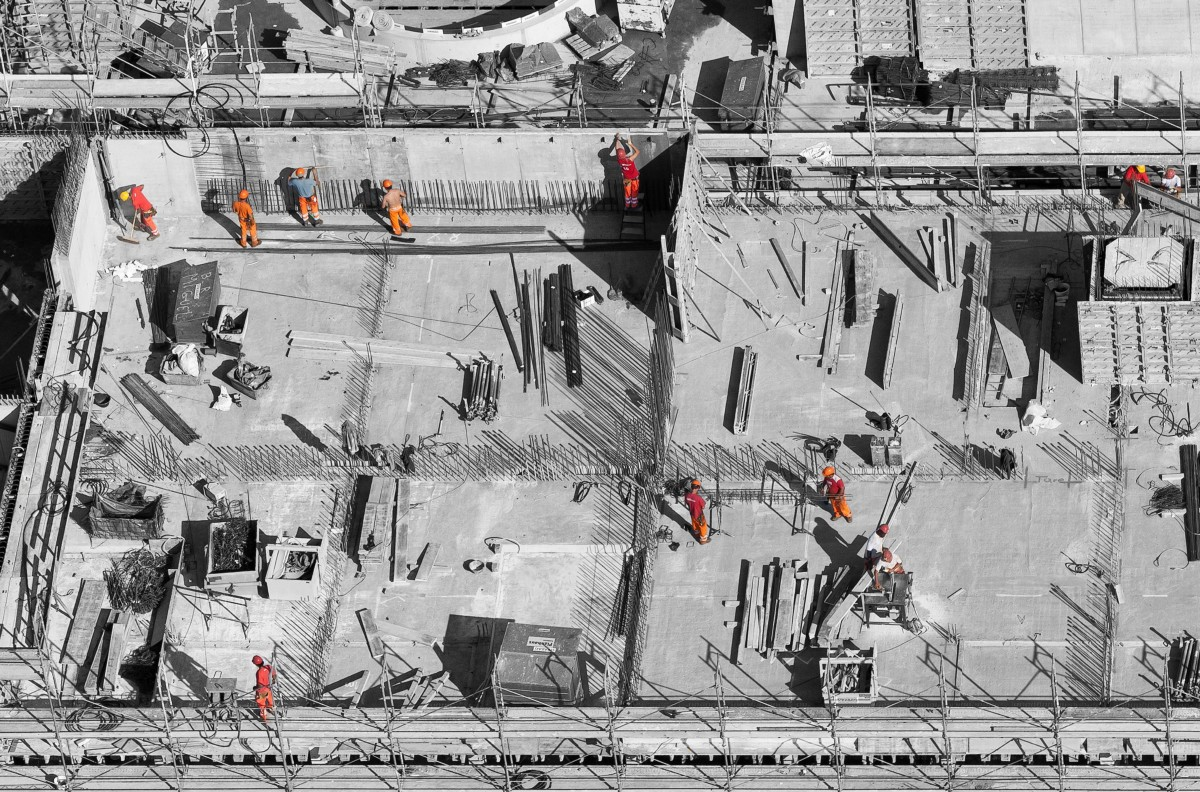

## Abstract

###  Concrete is the most important material in civil engineering. Theconcrete compressive strength is a highly nonlinear function of age andingredients. These ingredients include cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, and fine aggregate

## Data Characteristics

### The actual concrete compressive strength (MPa) for a given mixture under a specific age (days) was determined from laboratory.

## Time Line o fthe Project:
- Data Analysis
- Data Preprocessing
- Feature Engineering
- Model Building using DL
- Model Building using Auto Keras

**Importing Libraries**

In [57]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib 

In [58]:
path_name = input("Enter the path name:")
print("Entered path name",path_name)

Enter the path name:/home/kalyangopu/Documents/miniproject/concrete_data.csv
Entered path name /home/kalyangopu/Documents/miniproject/concrete_data.csv


In [59]:
df = pd.read_csv(path_name)
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [60]:
df.shape

(1030, 9)

## Data Analysis

In [61]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [63]:
df.isna().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

### Heatmap

<Axes: >

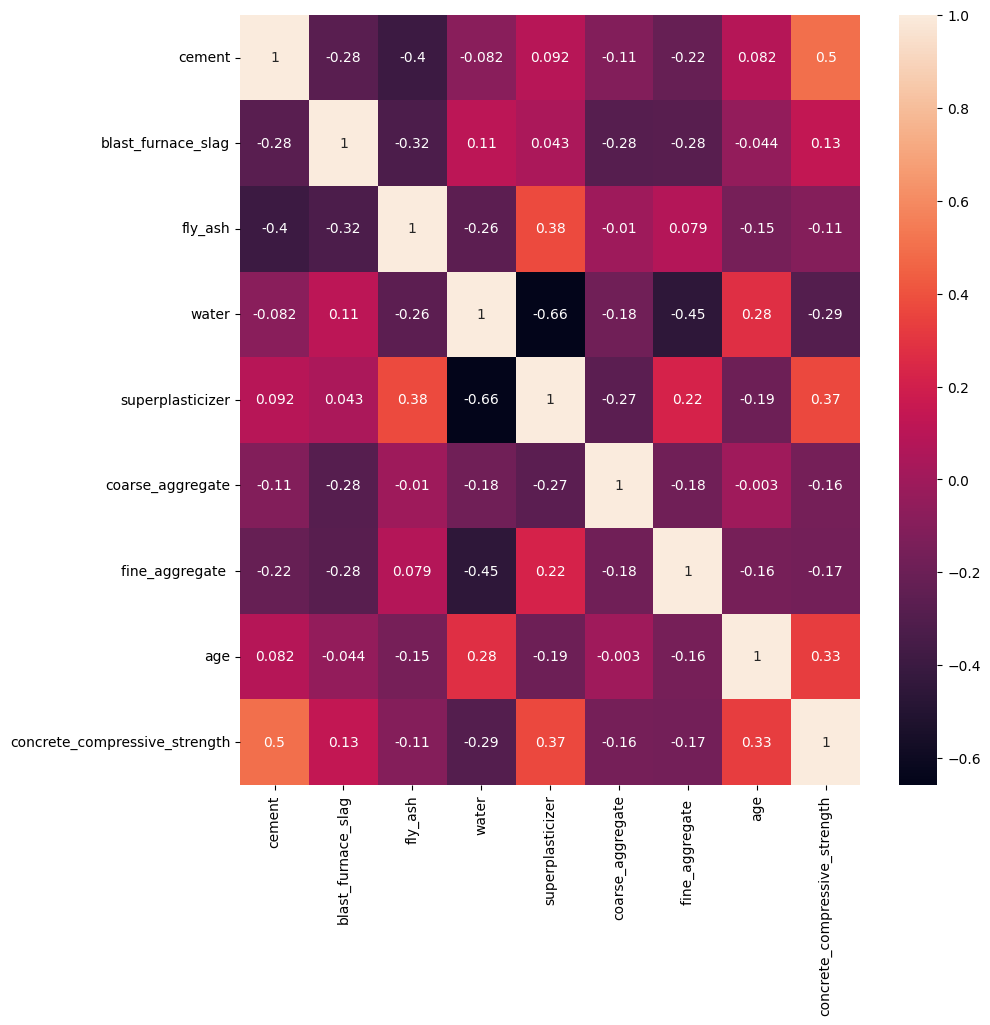

In [64]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)

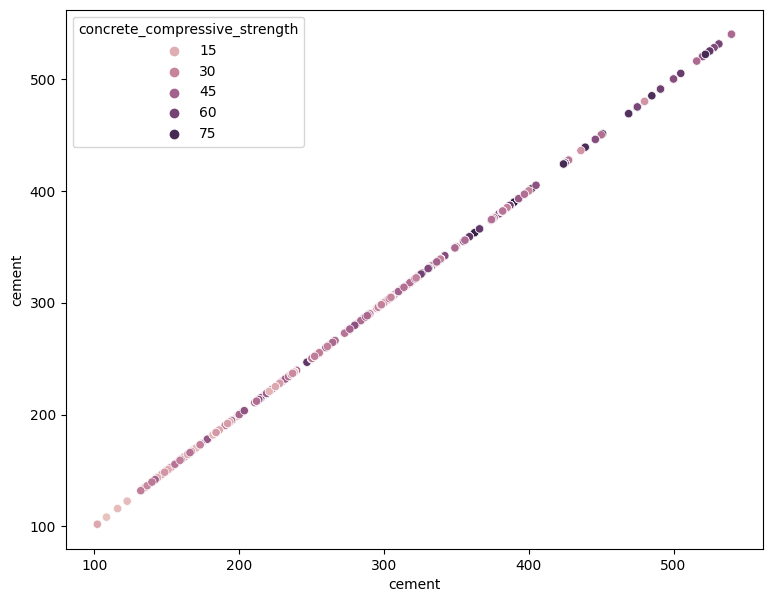

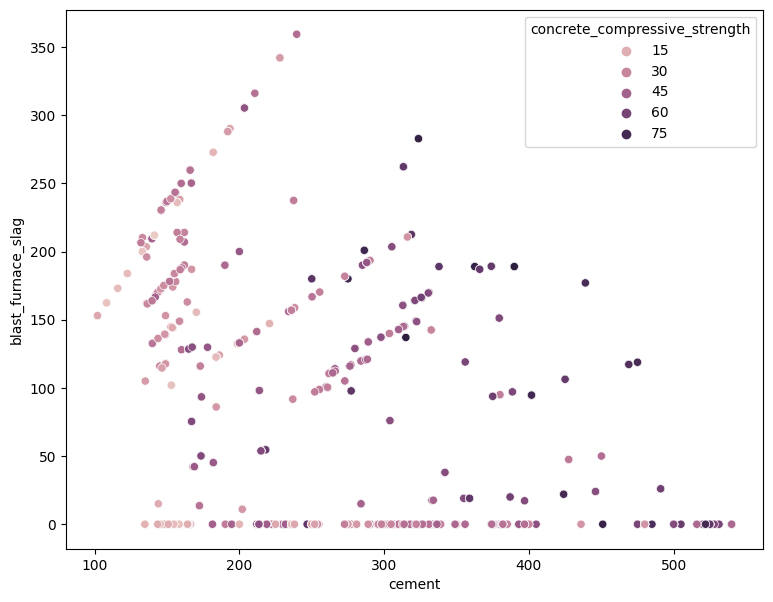

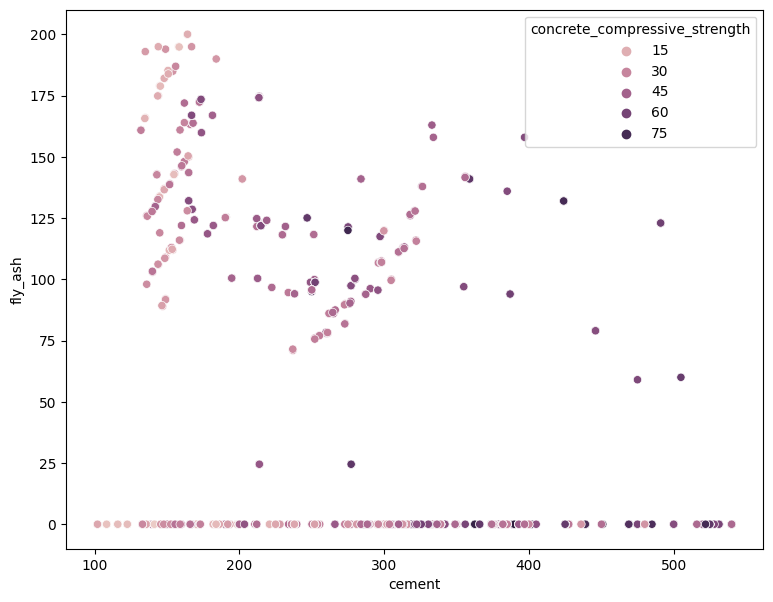

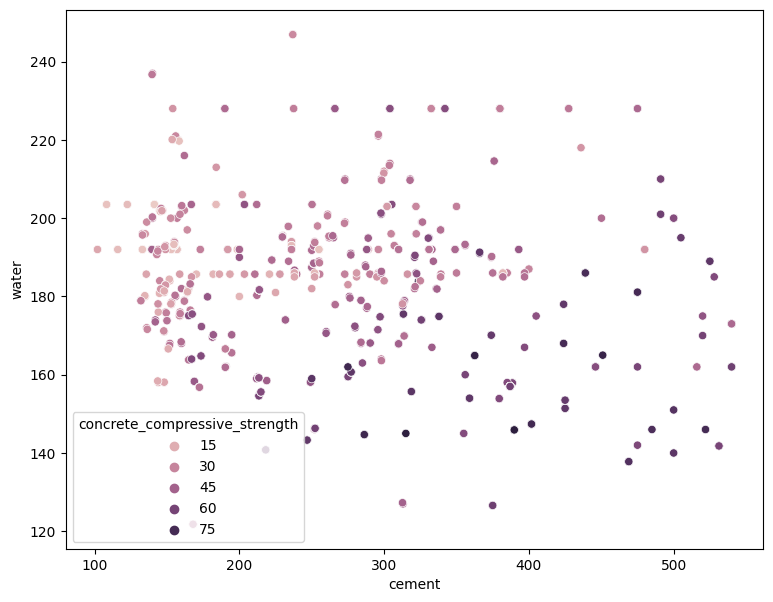

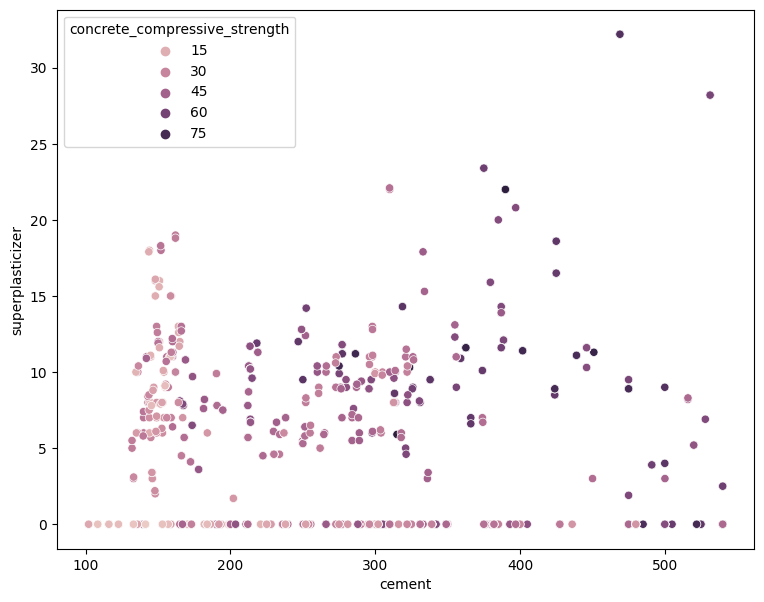

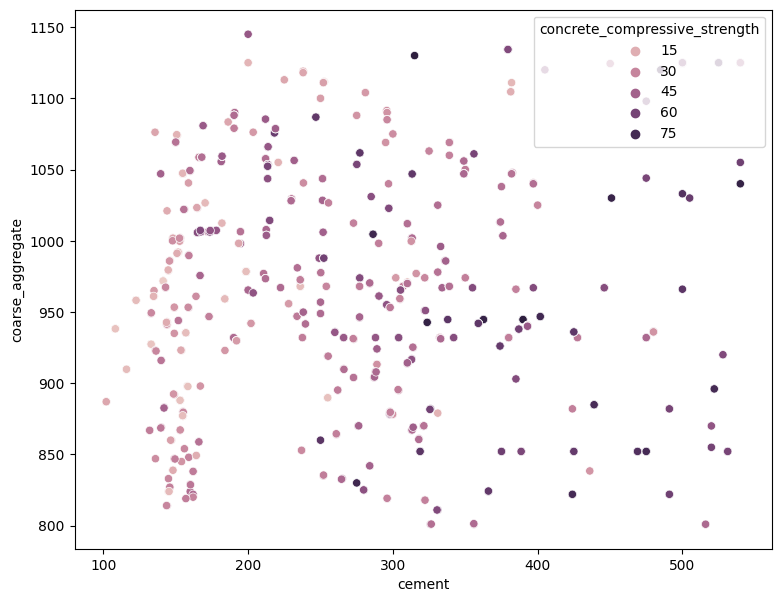

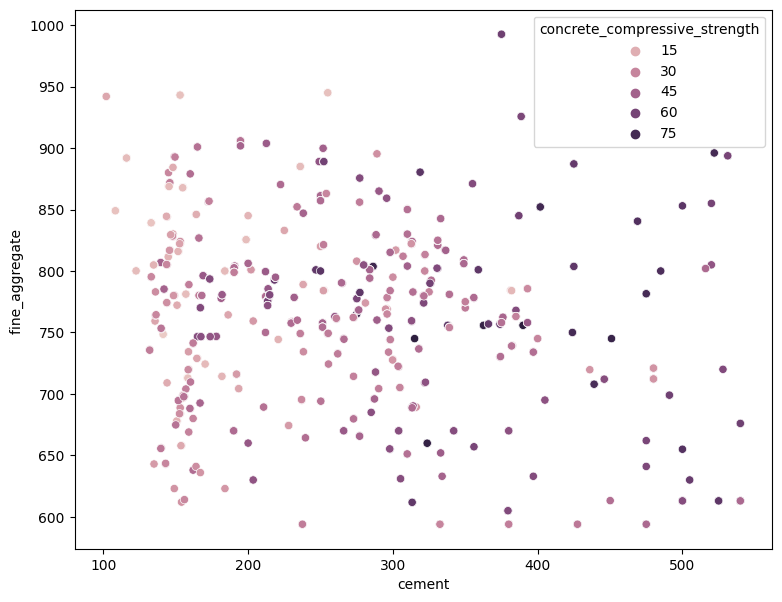

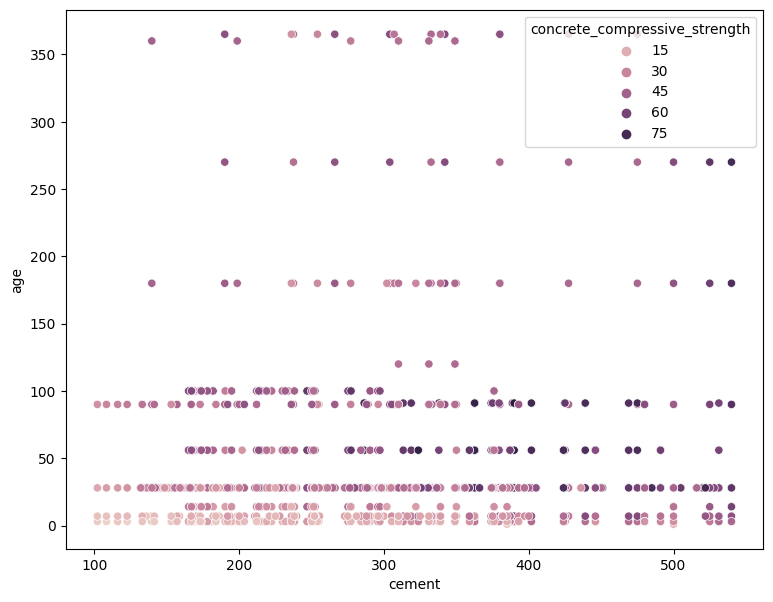

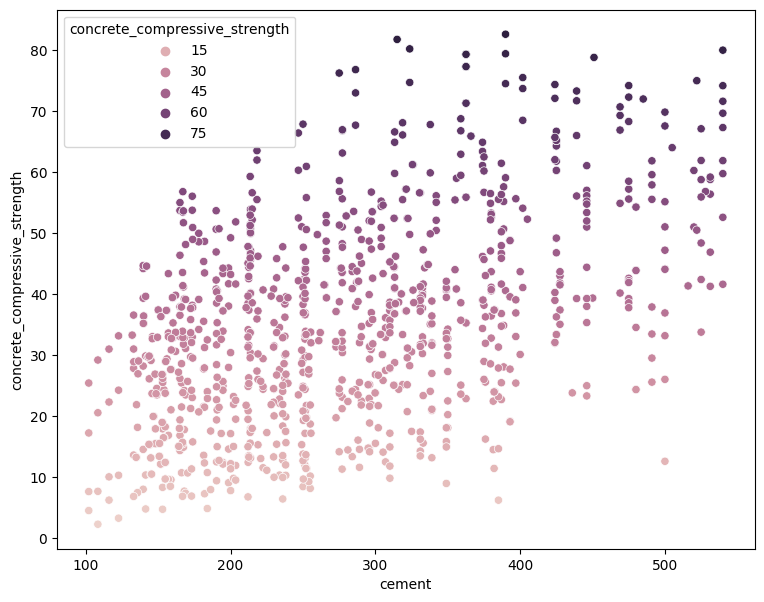

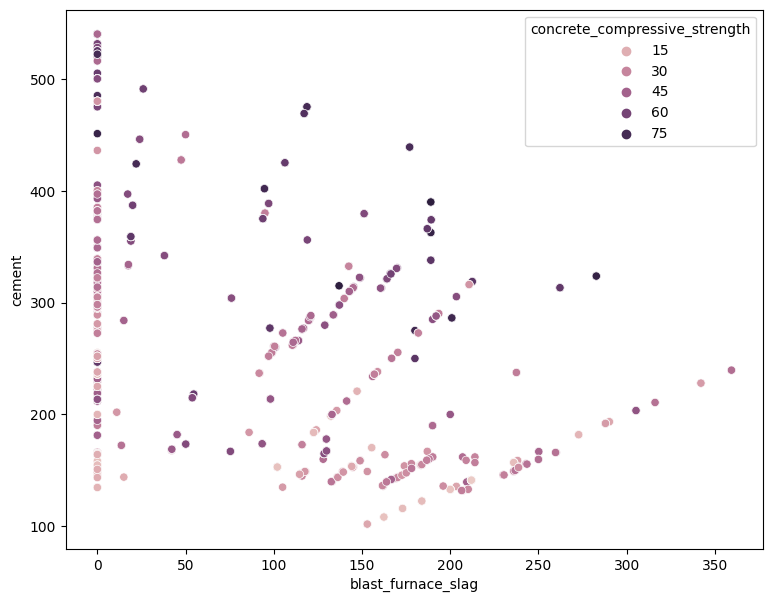

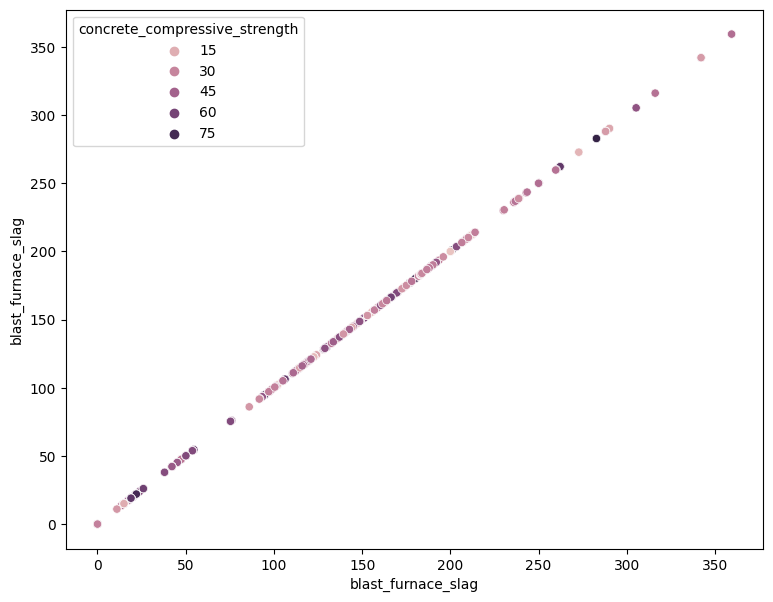

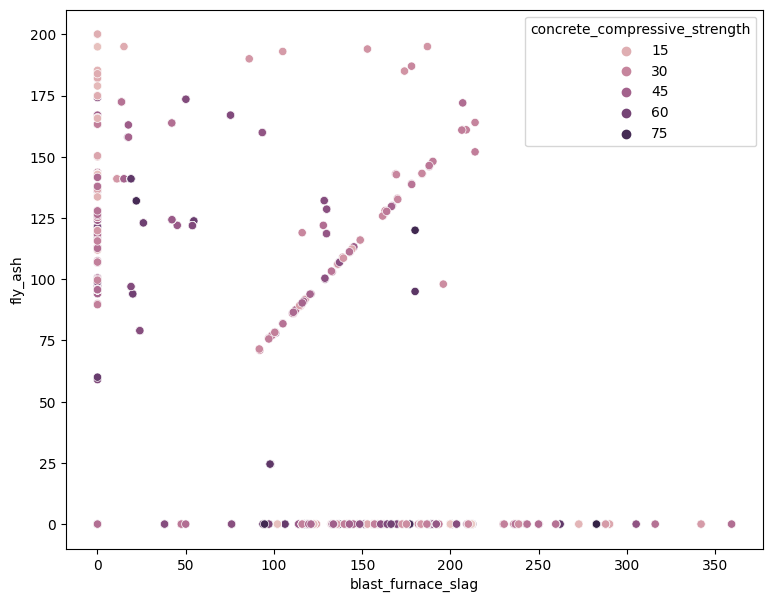

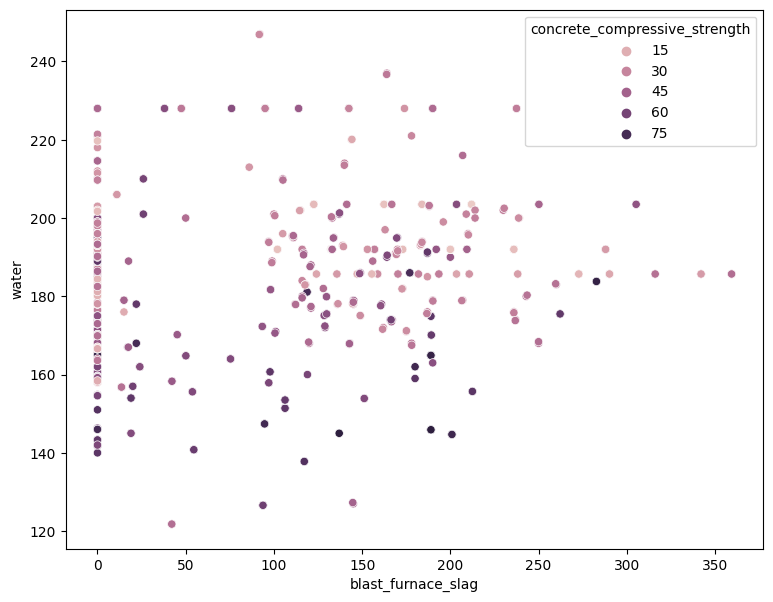

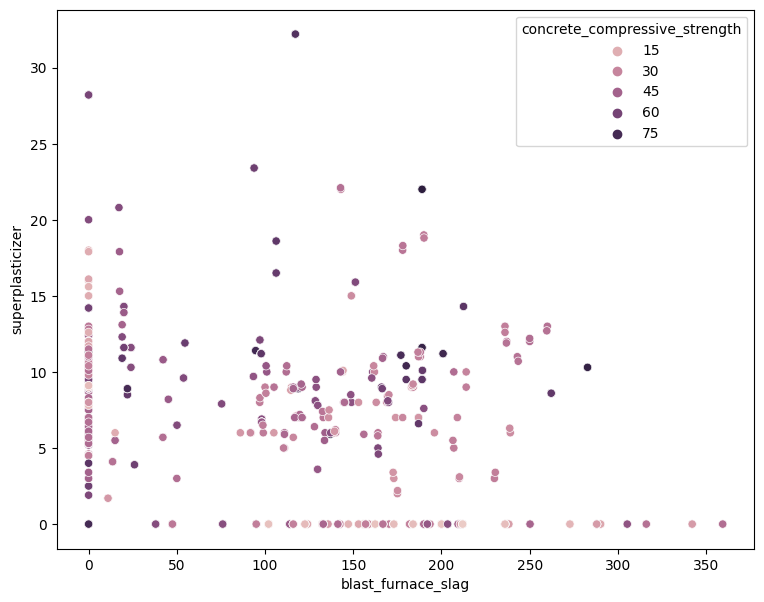

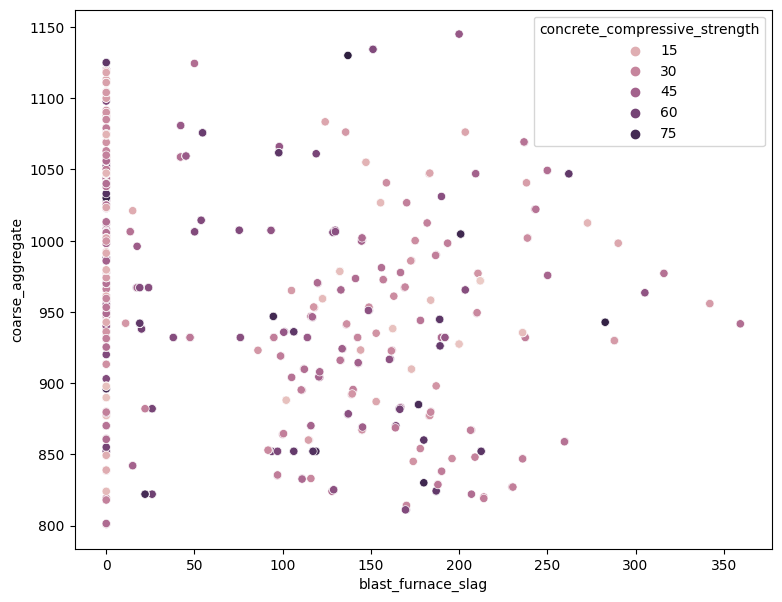

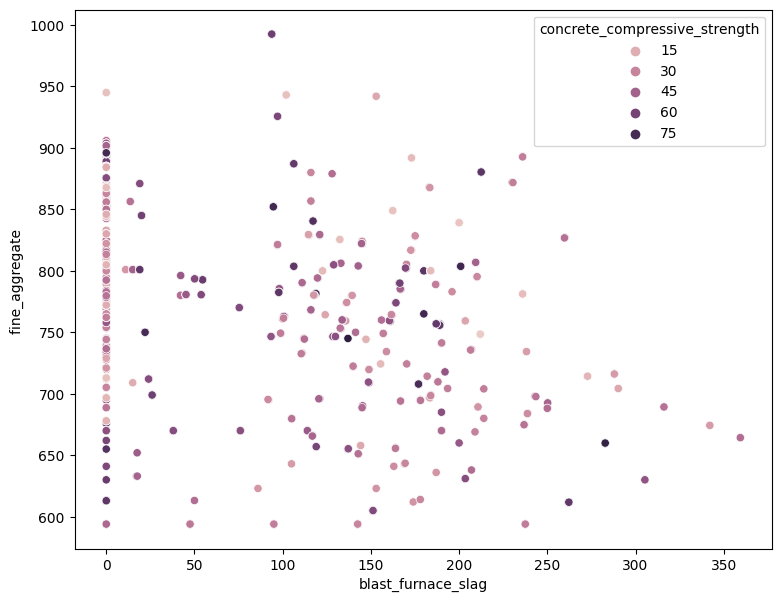

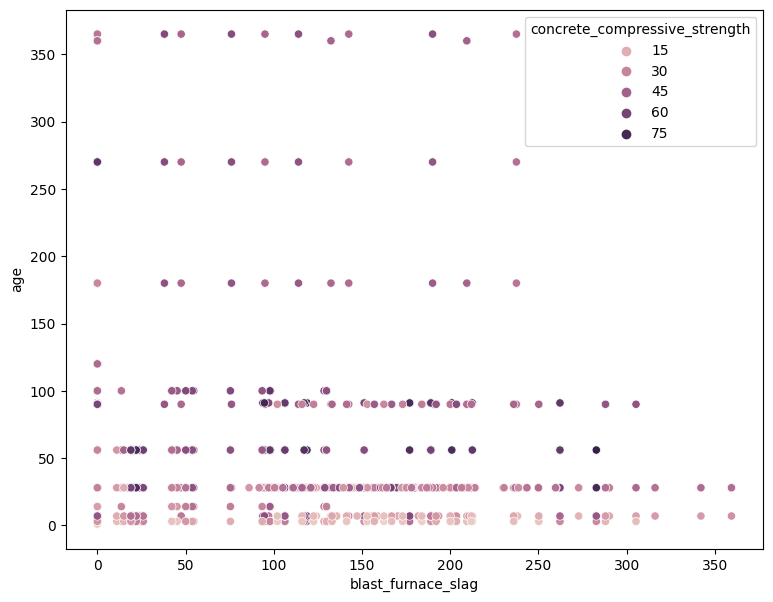

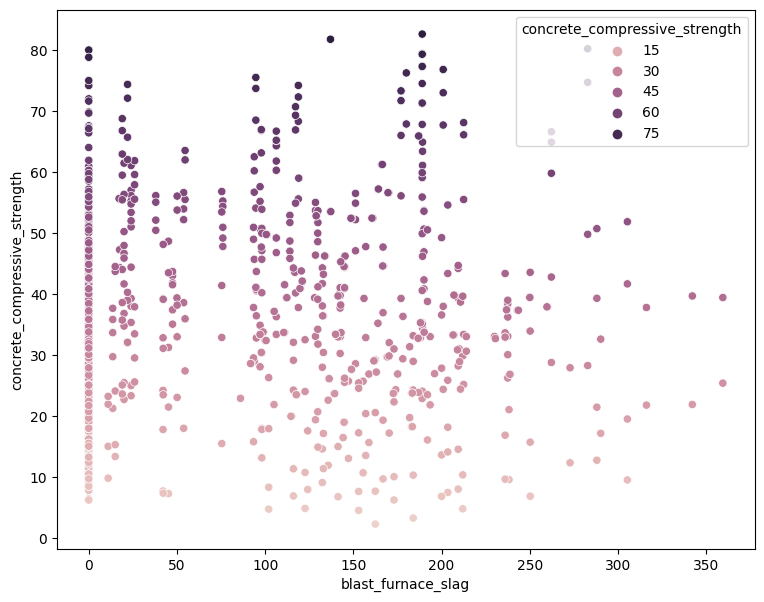

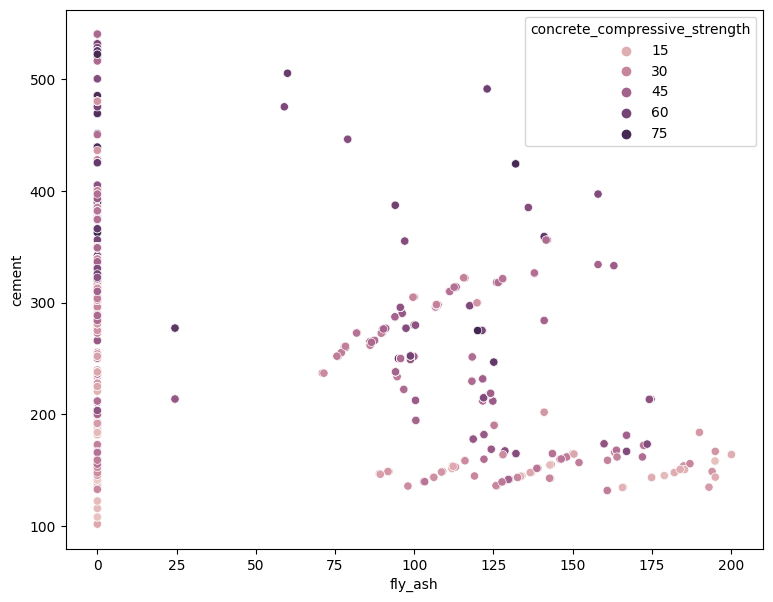

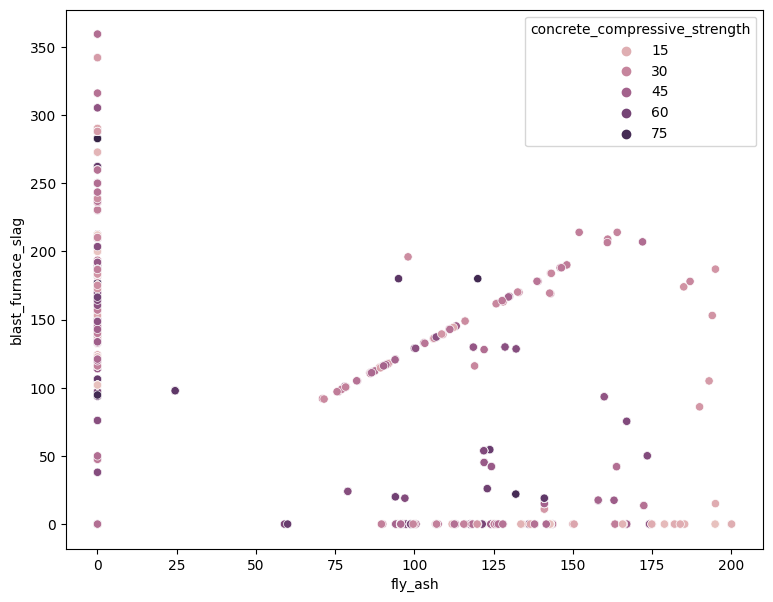

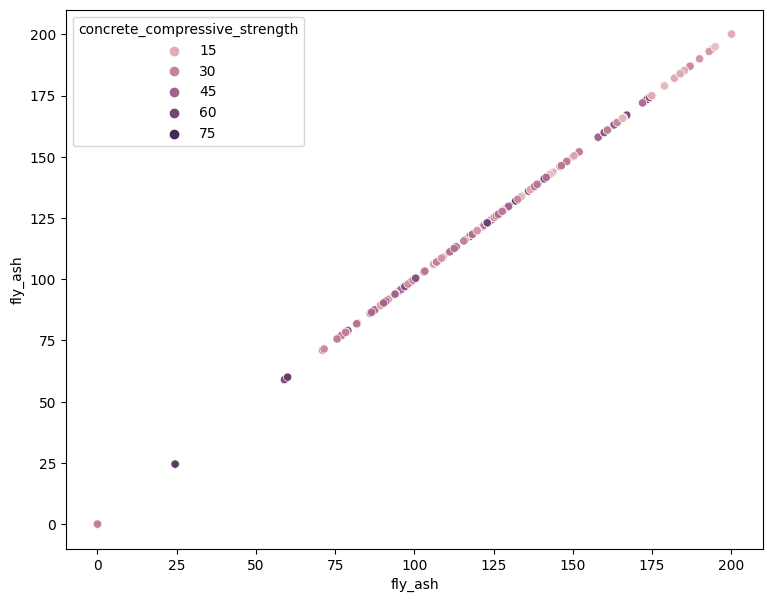

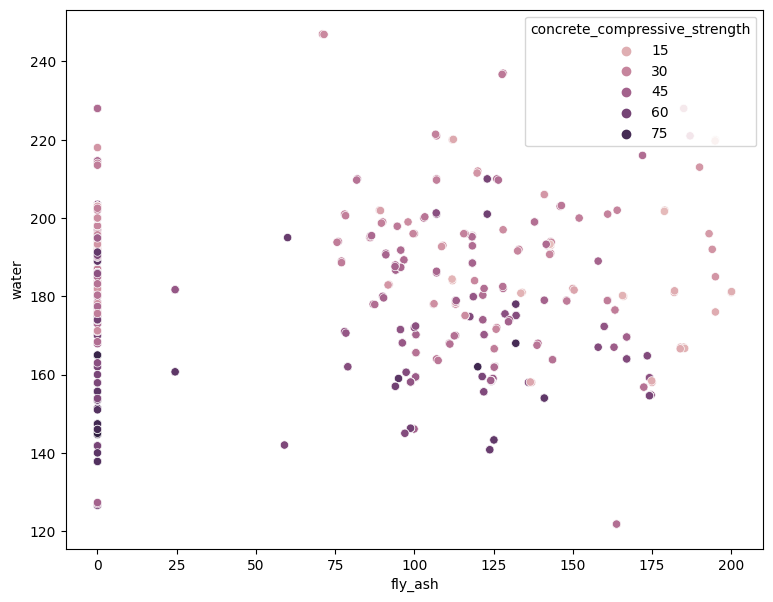

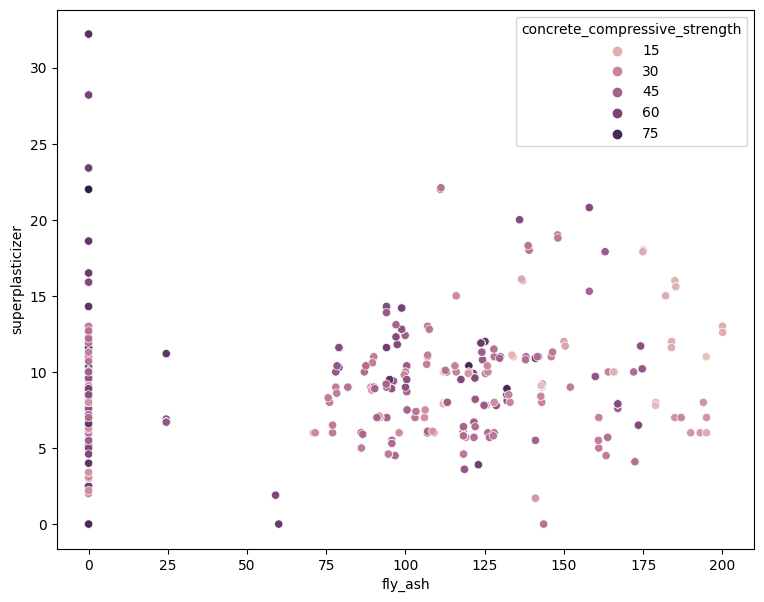

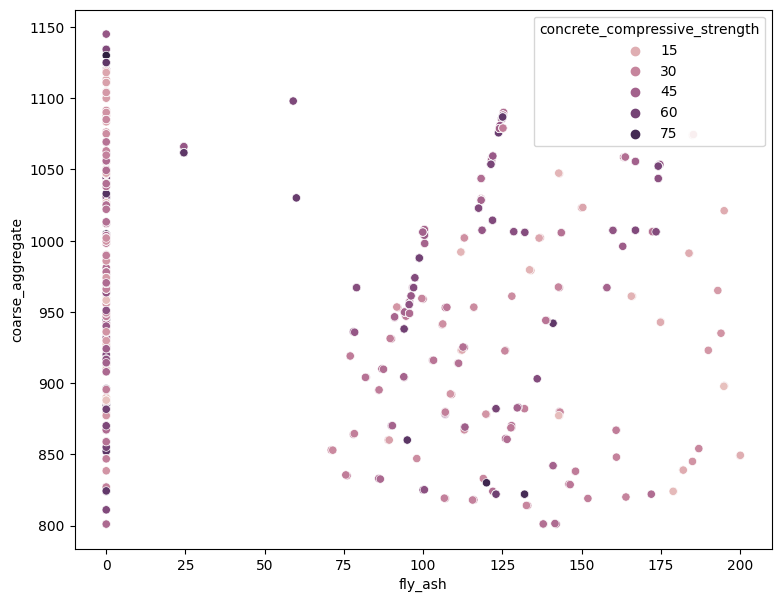

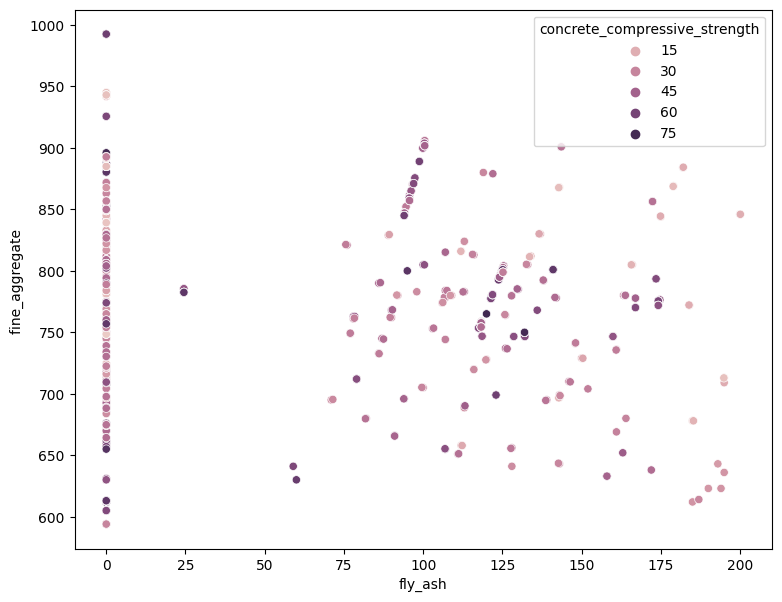

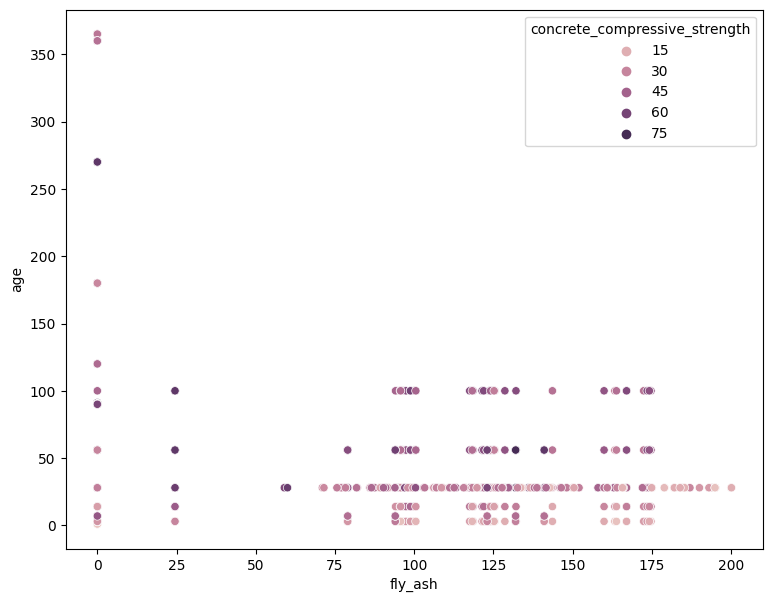

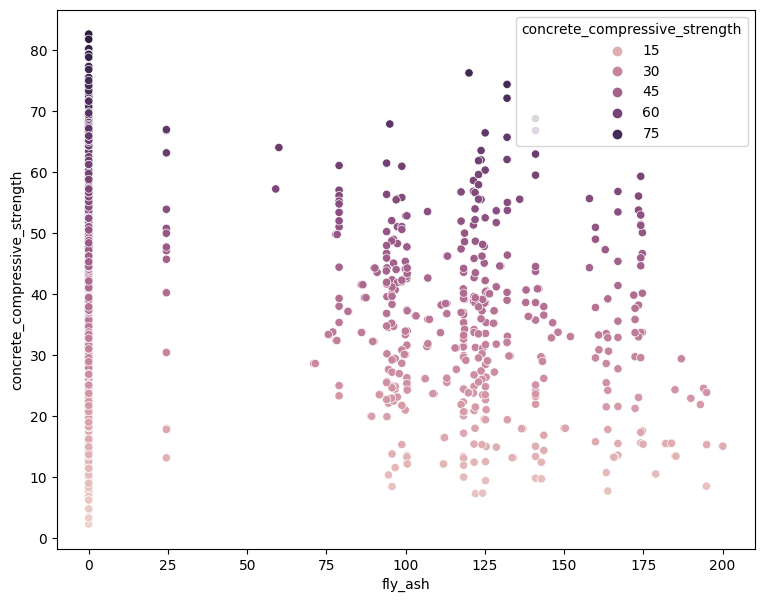

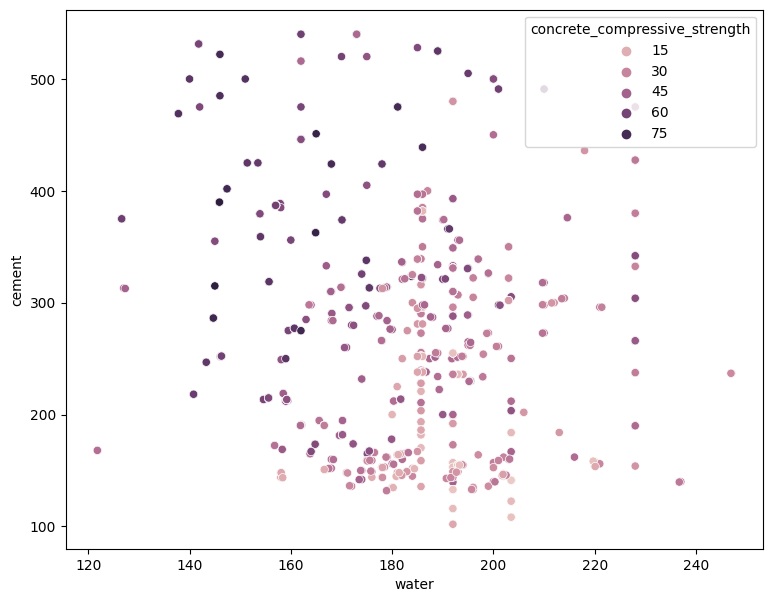

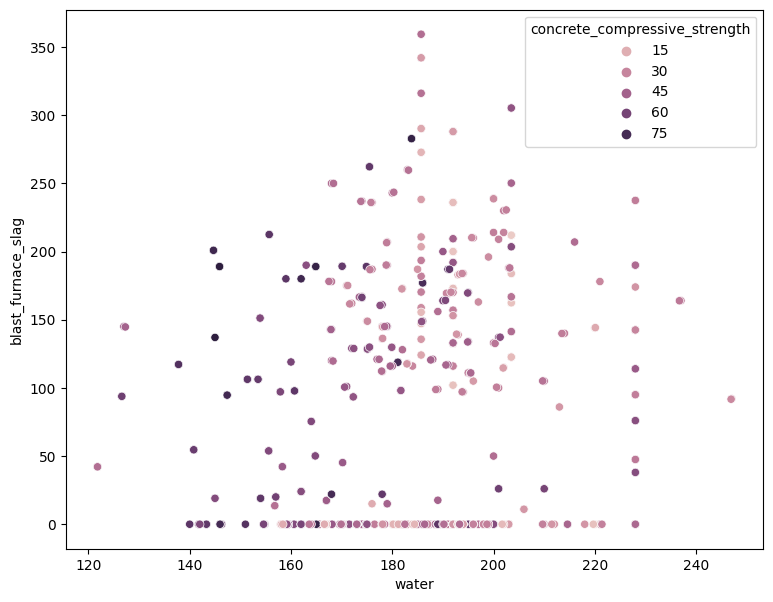

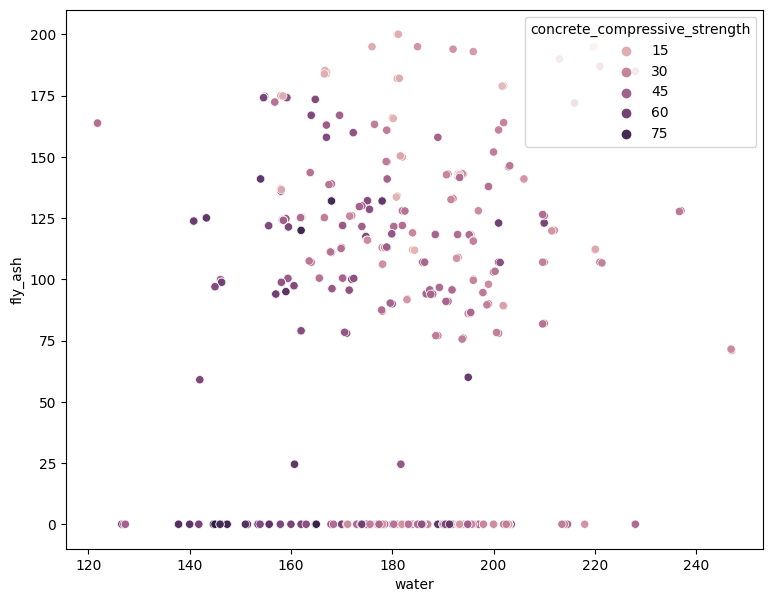

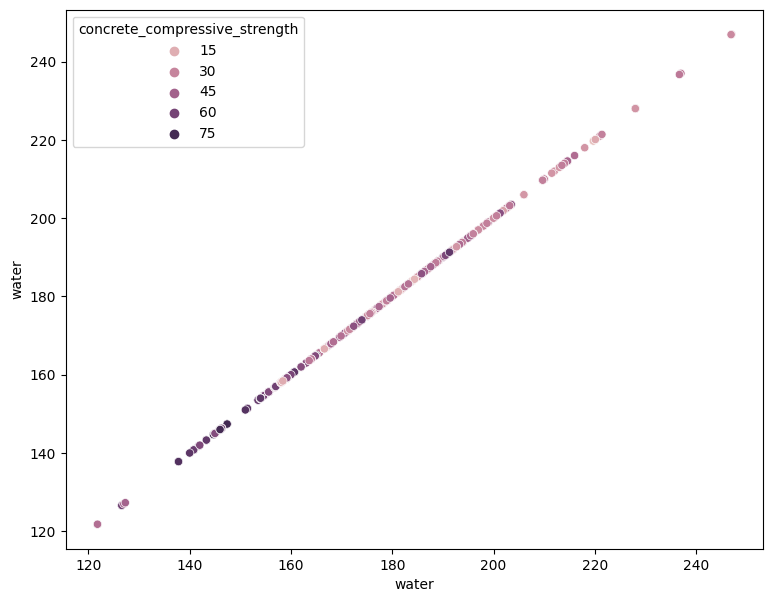

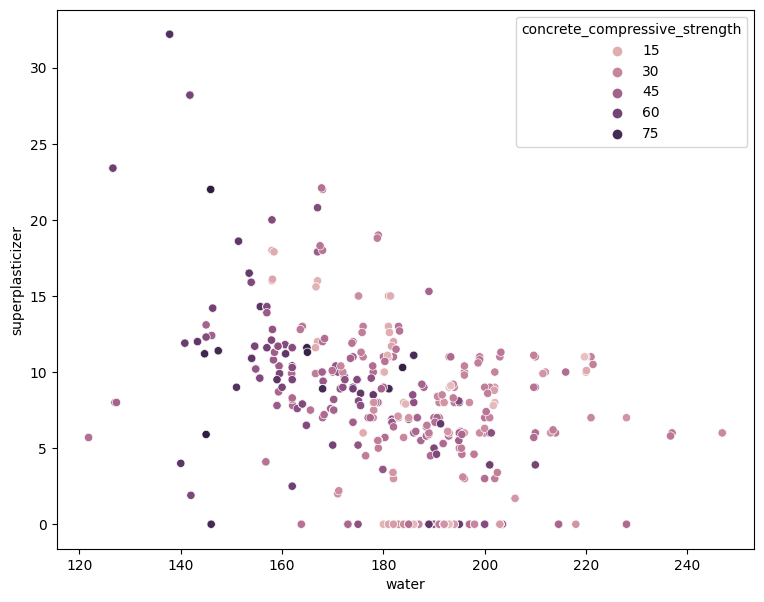

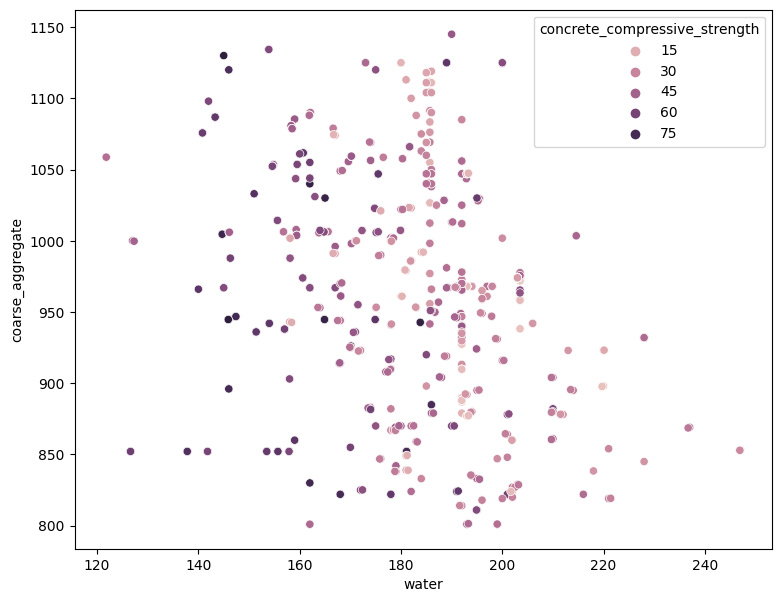

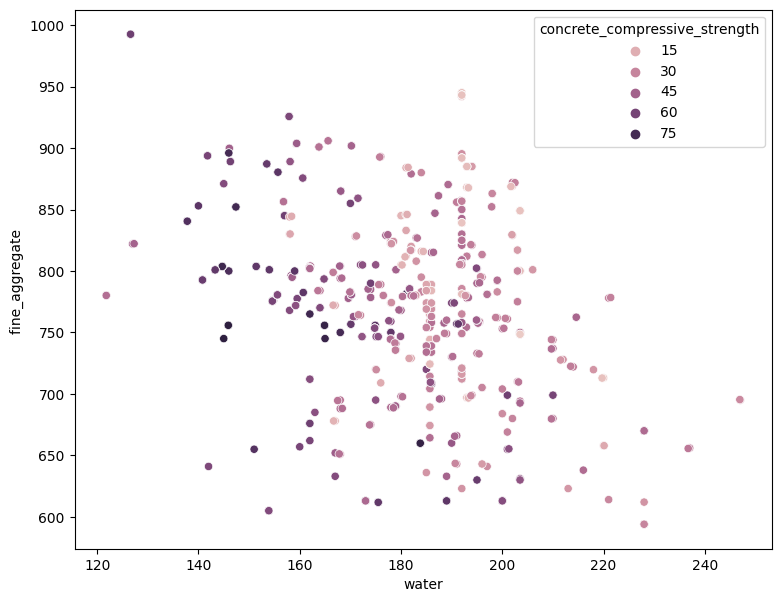

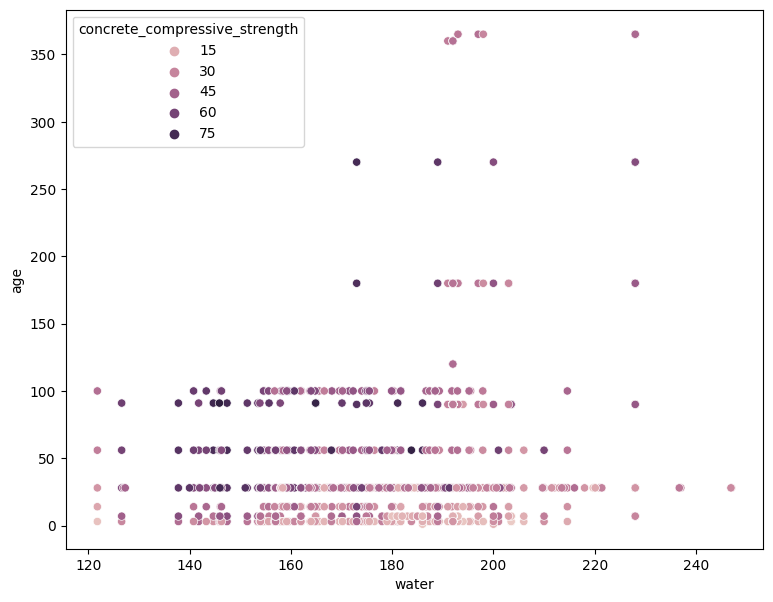

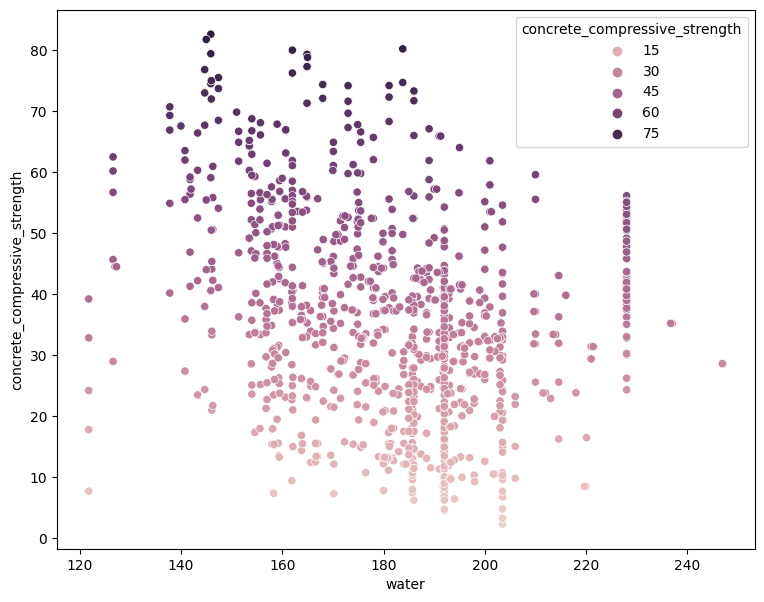

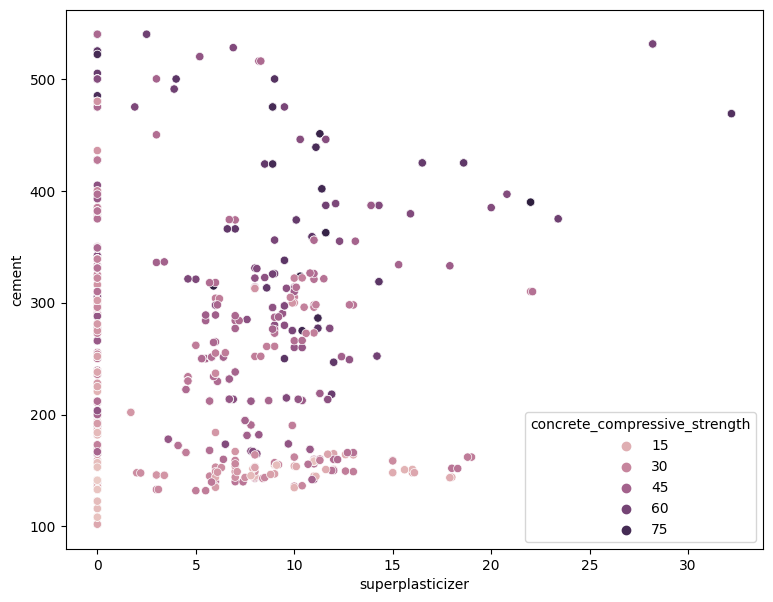

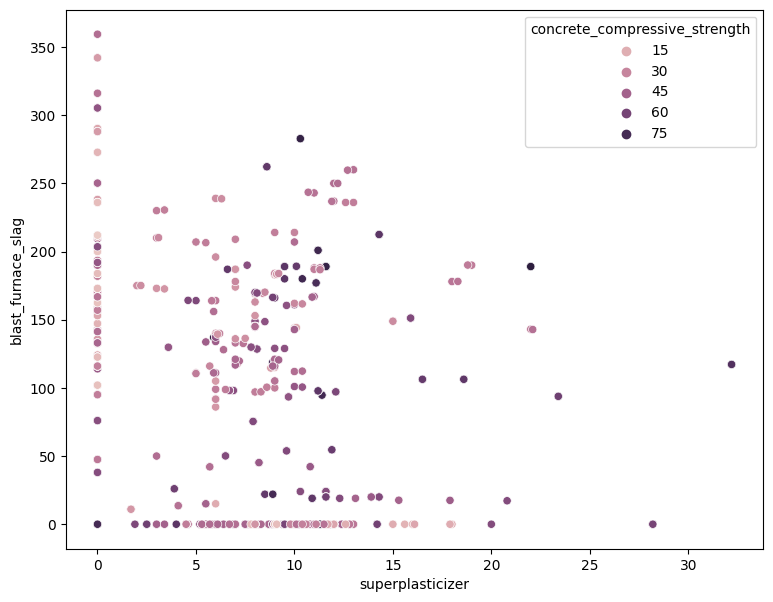

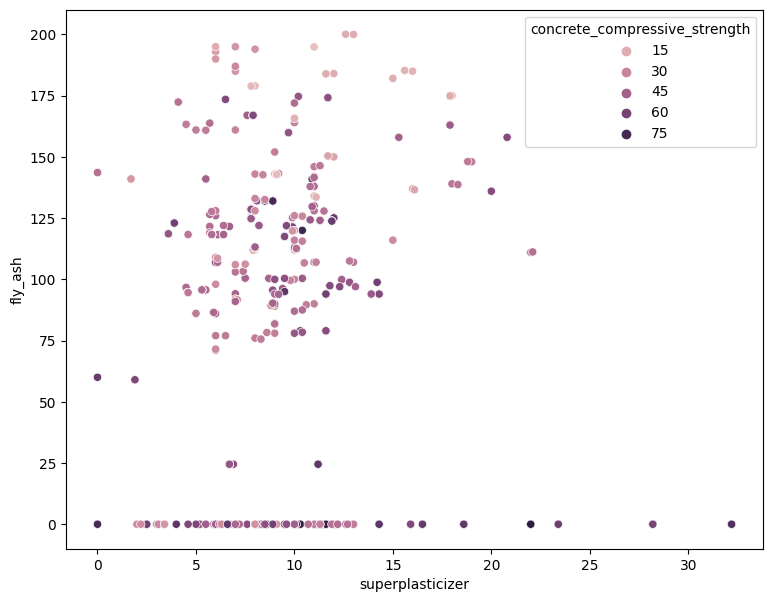

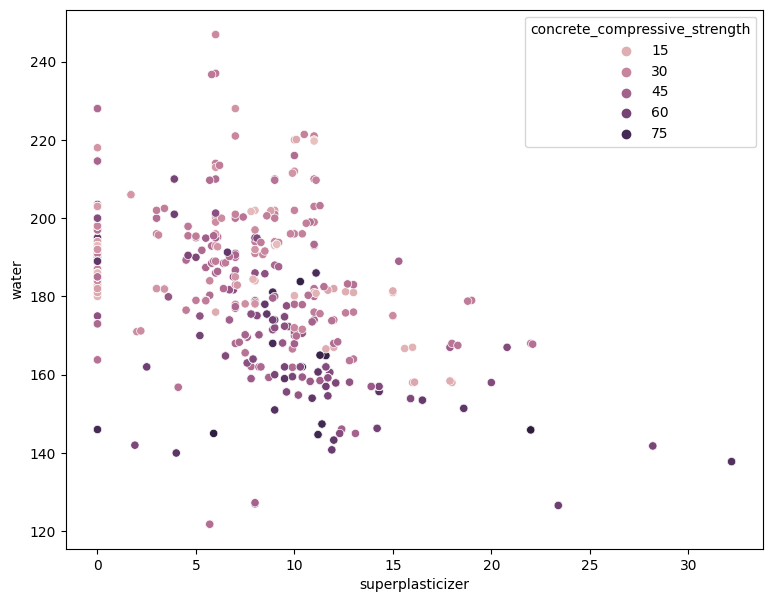

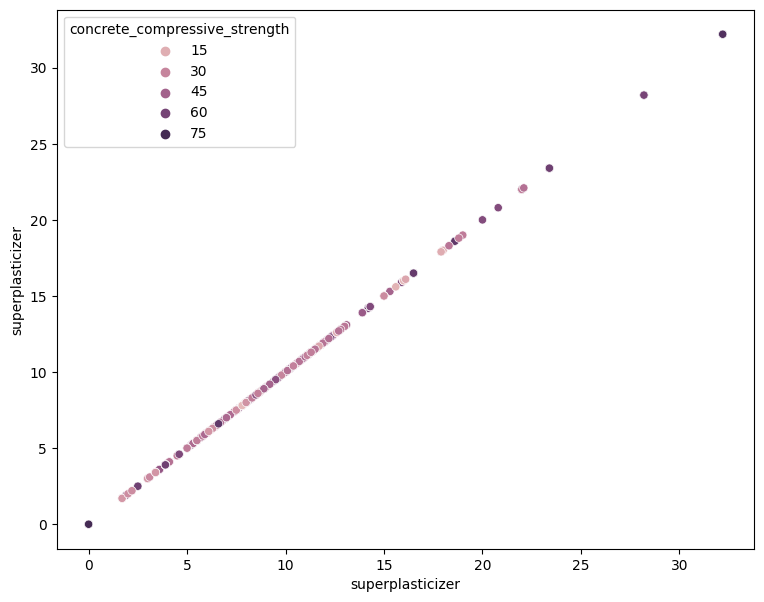

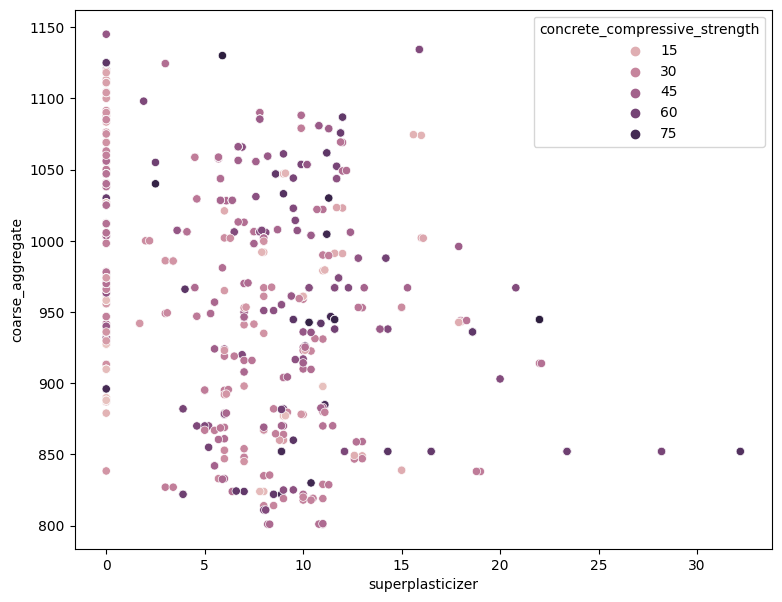

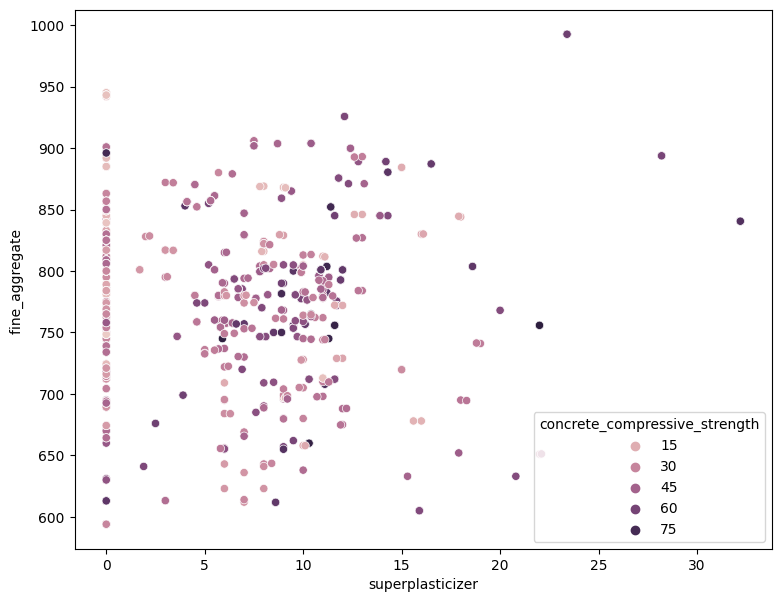

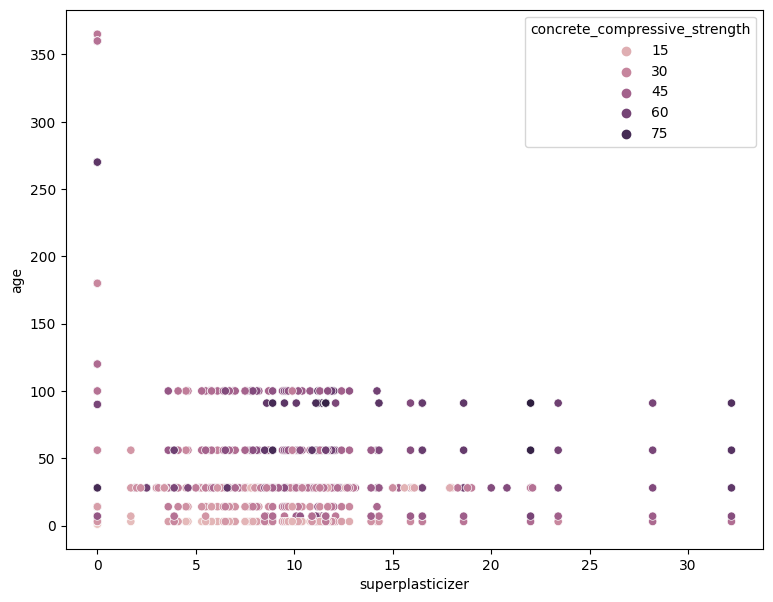

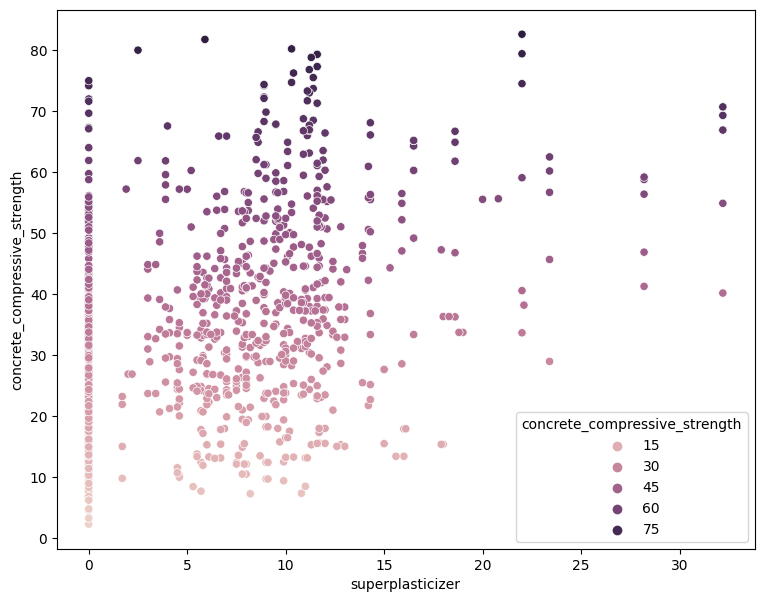

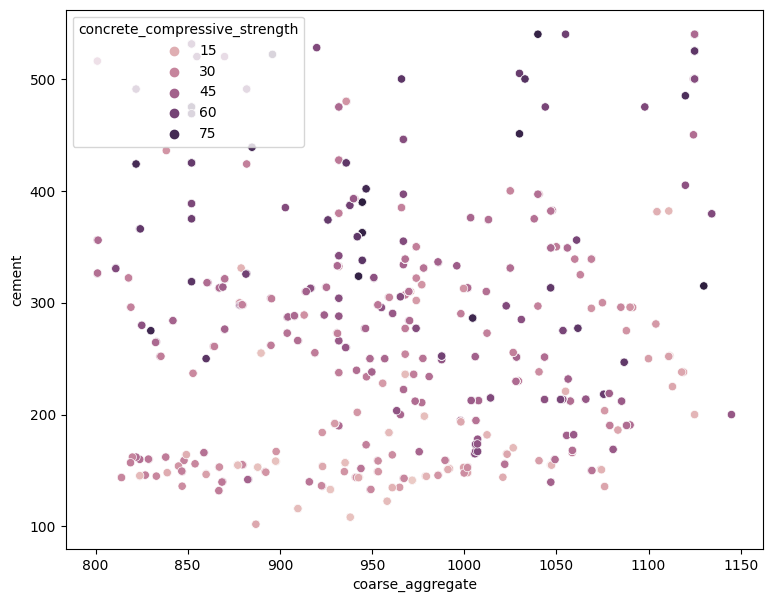

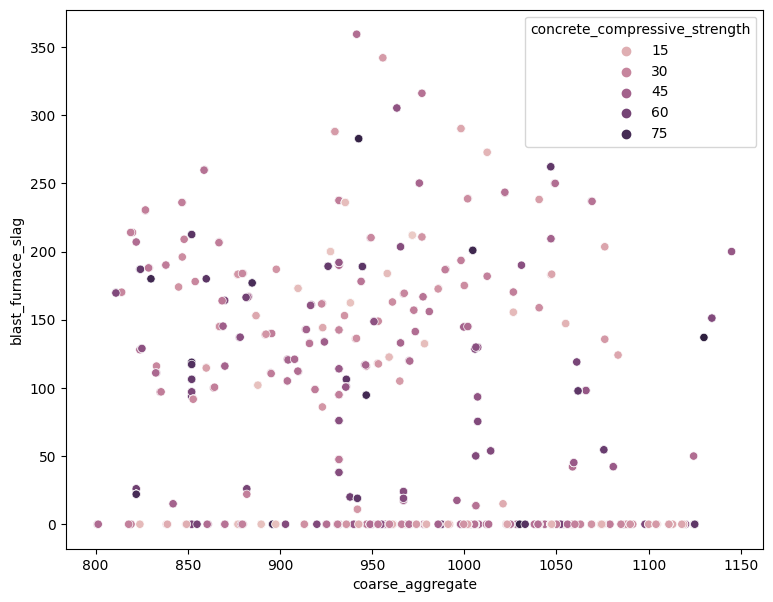

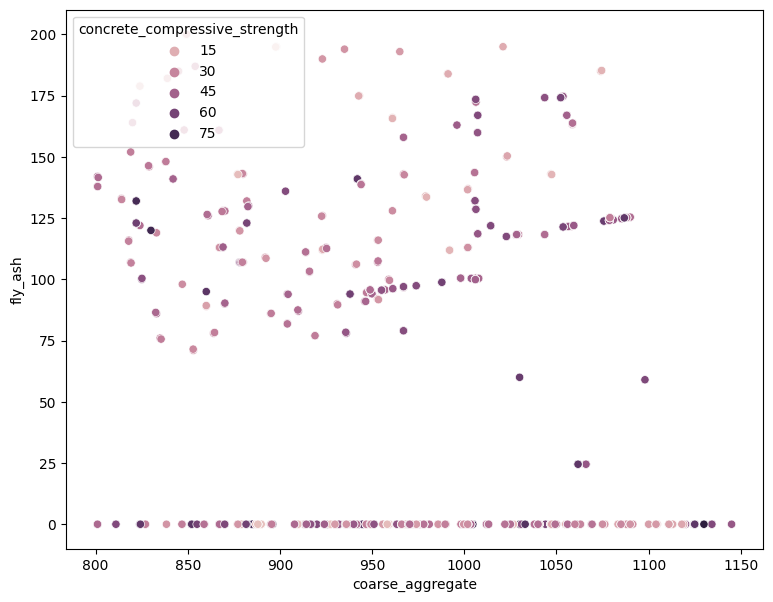

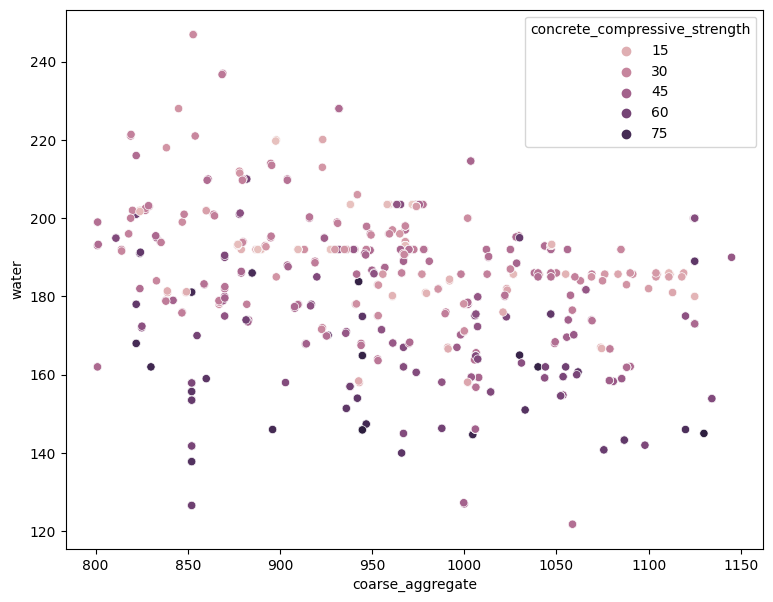

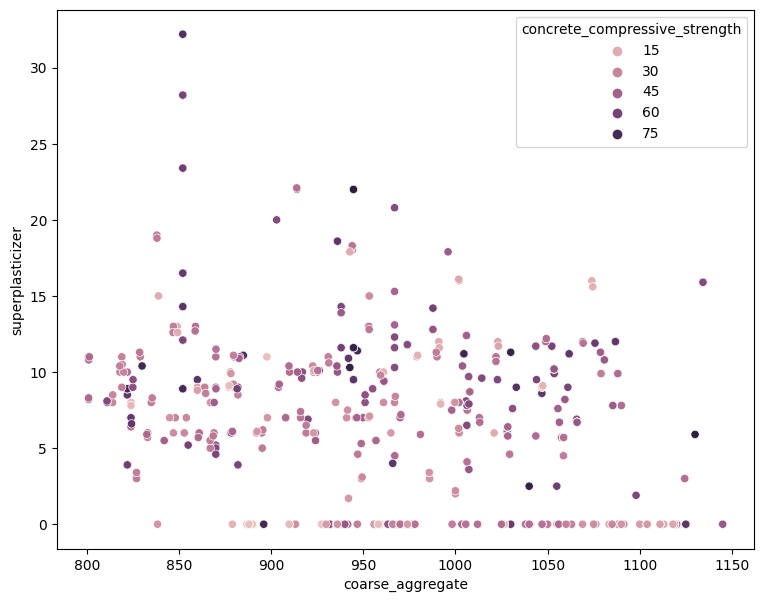

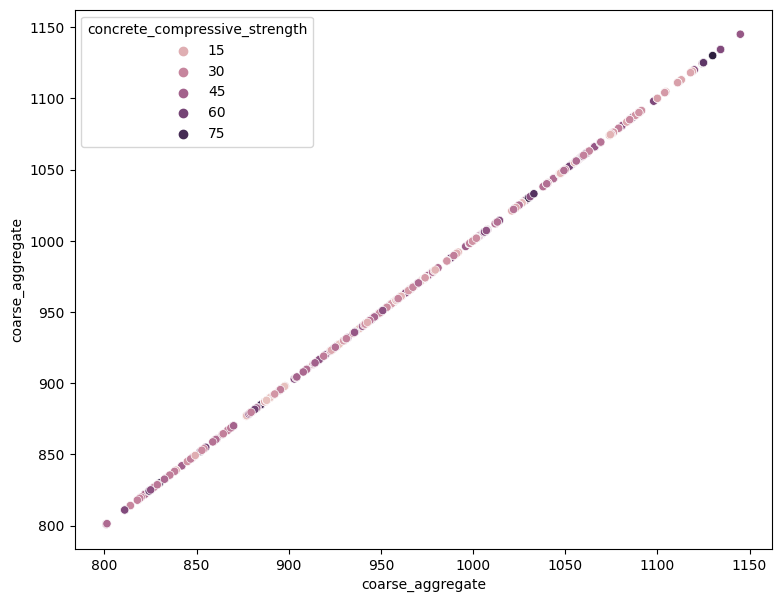

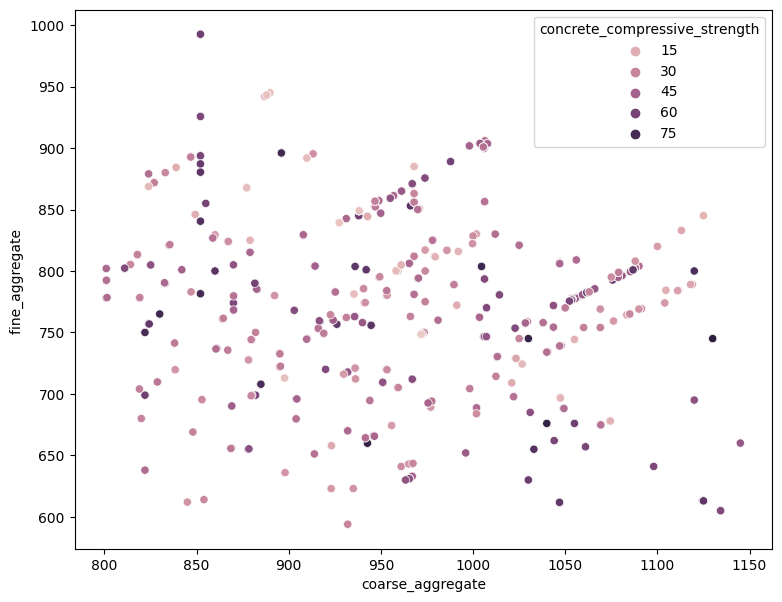

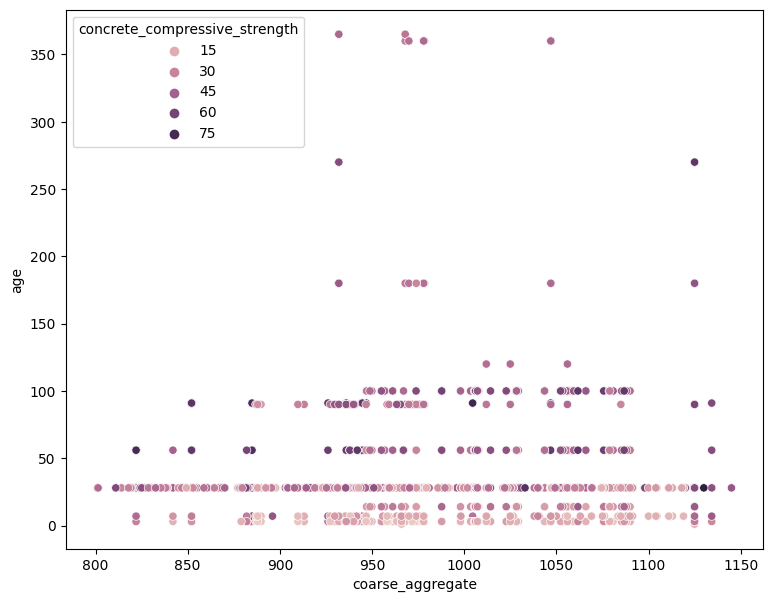

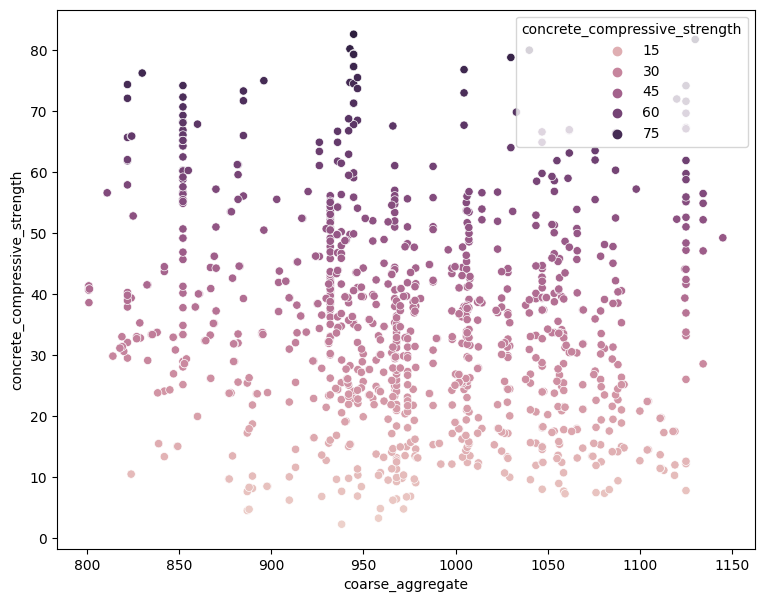

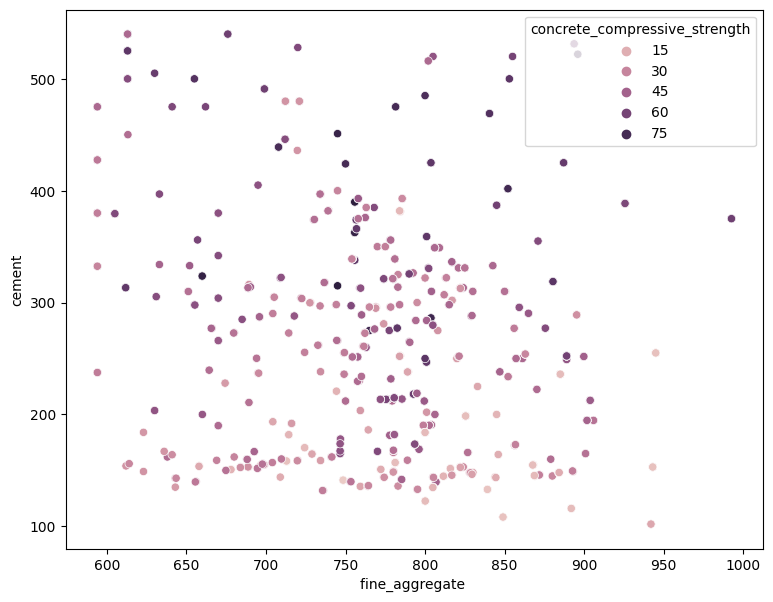

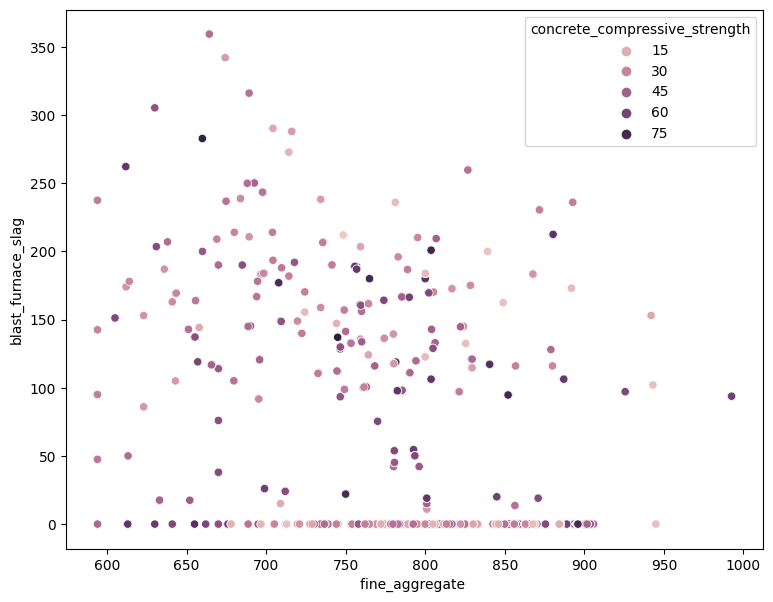

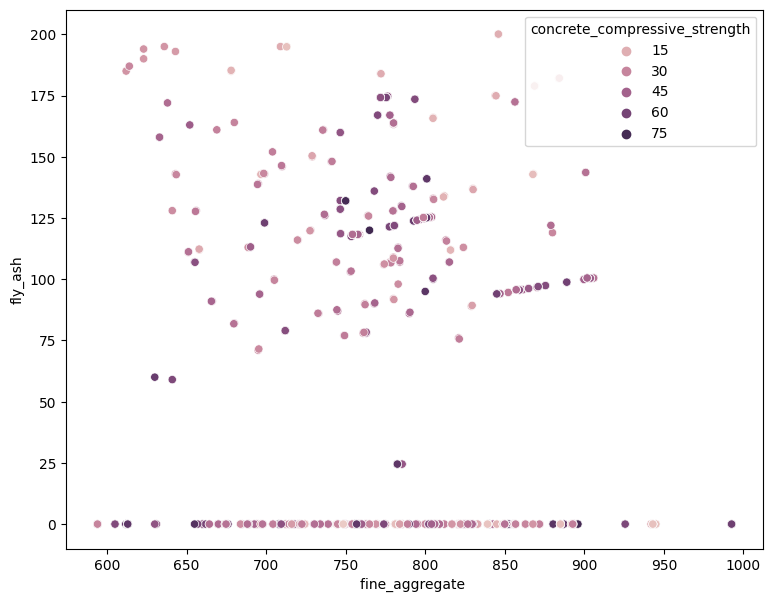

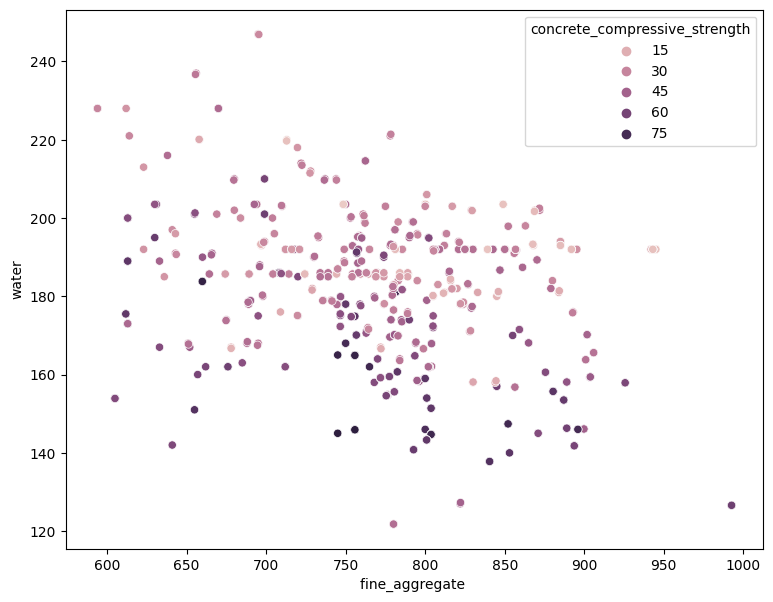

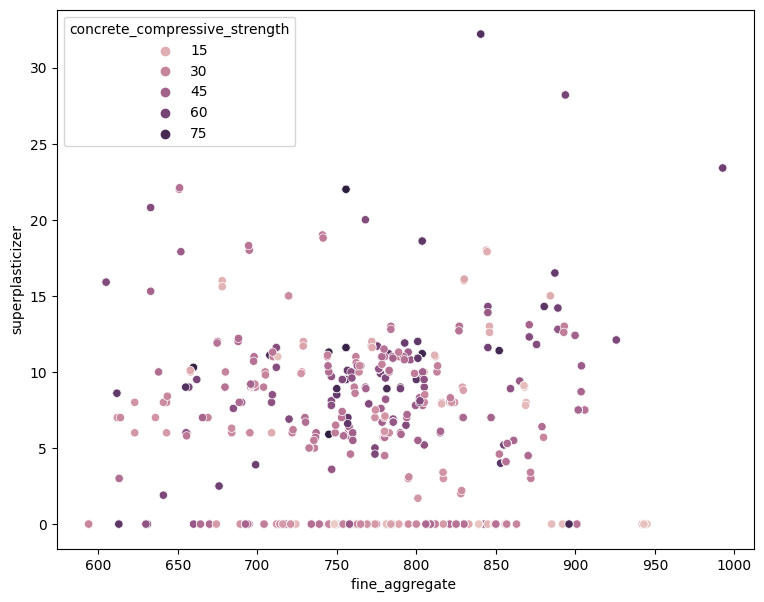

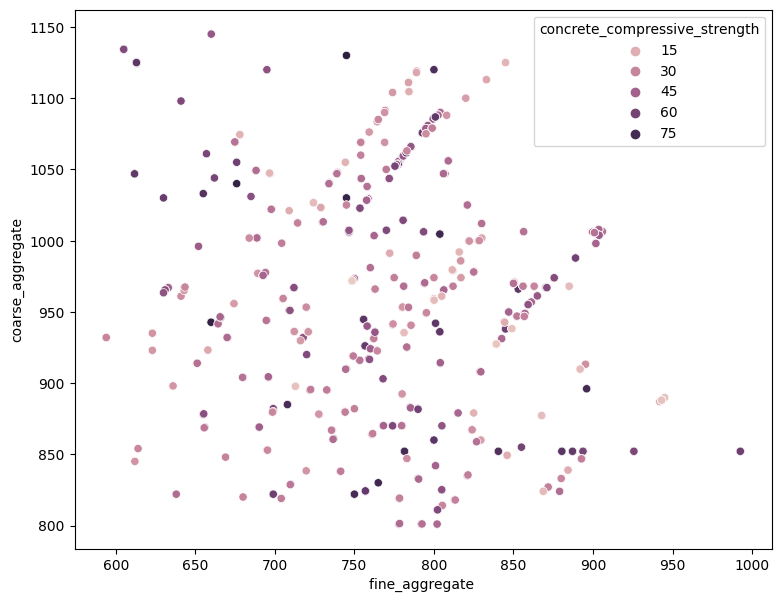

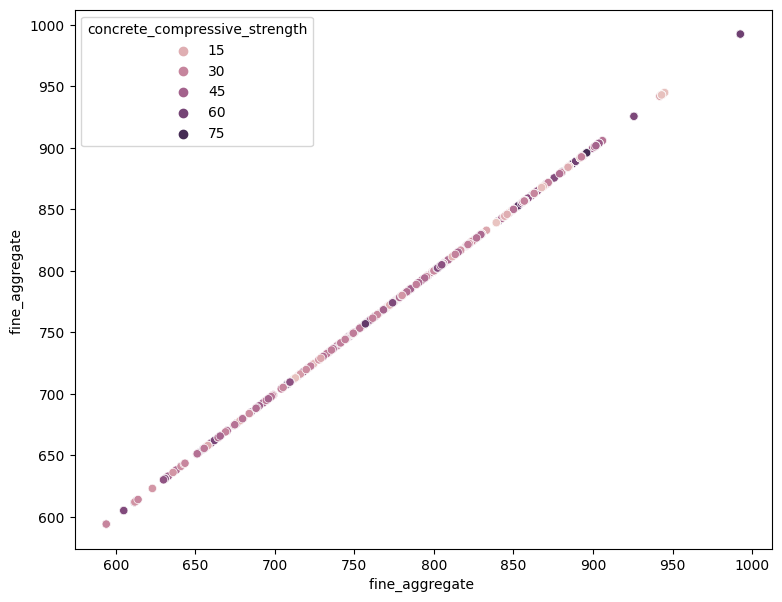

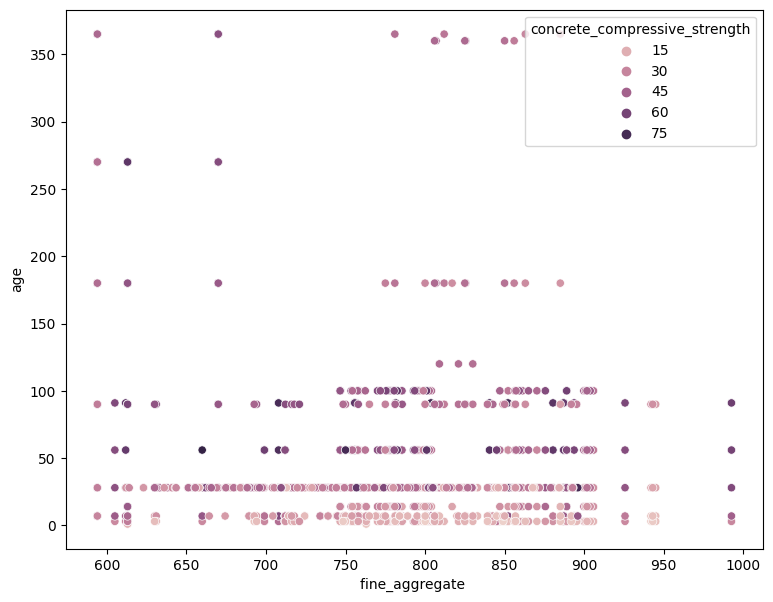

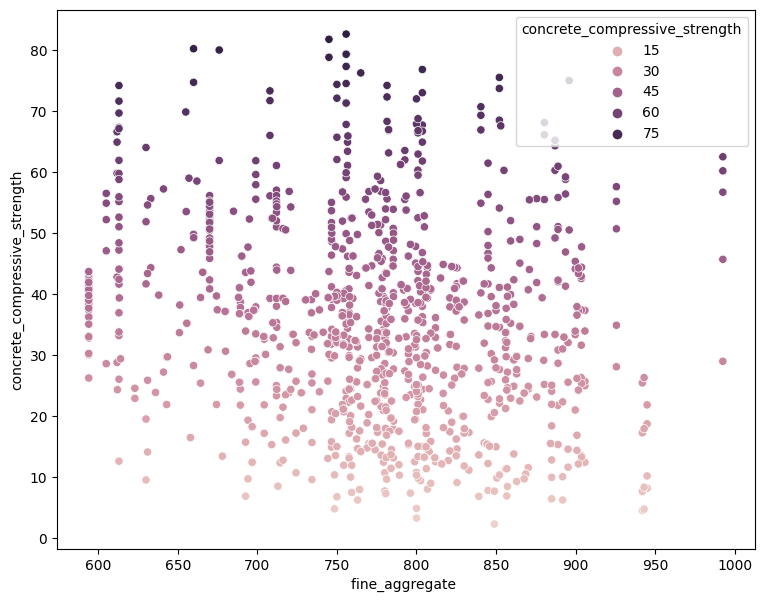

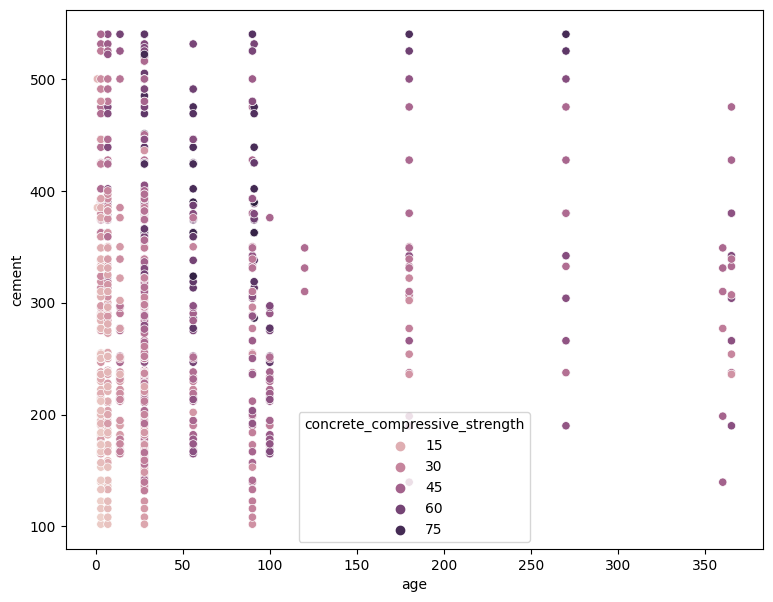

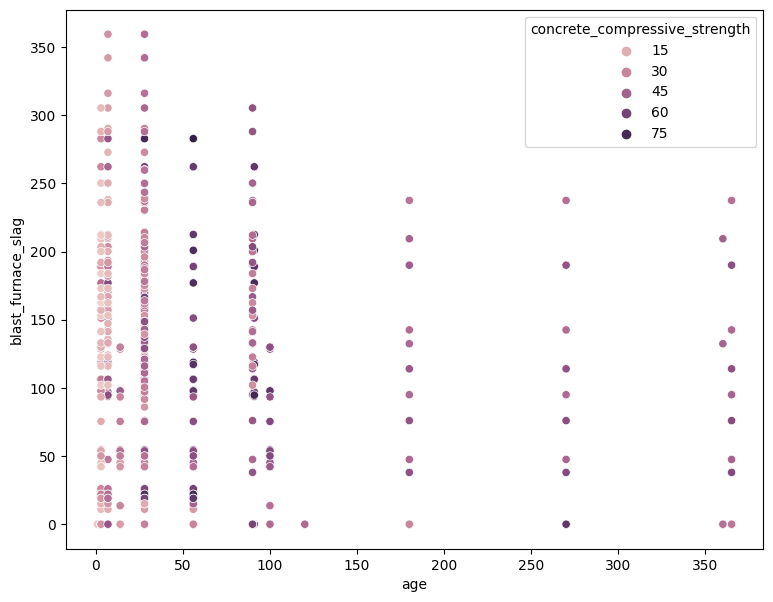

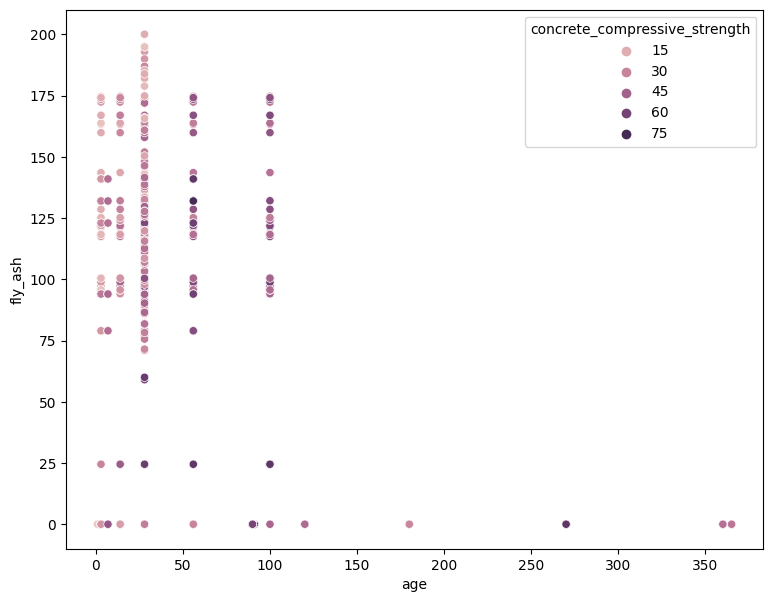

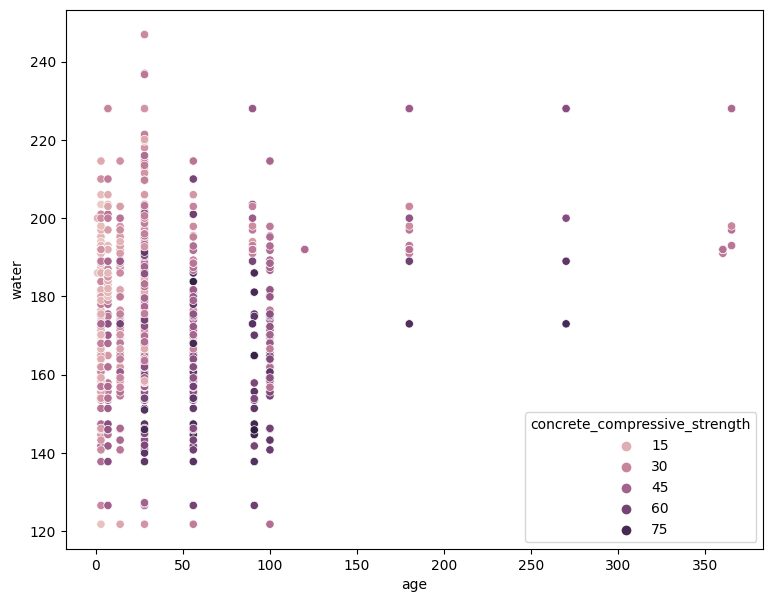

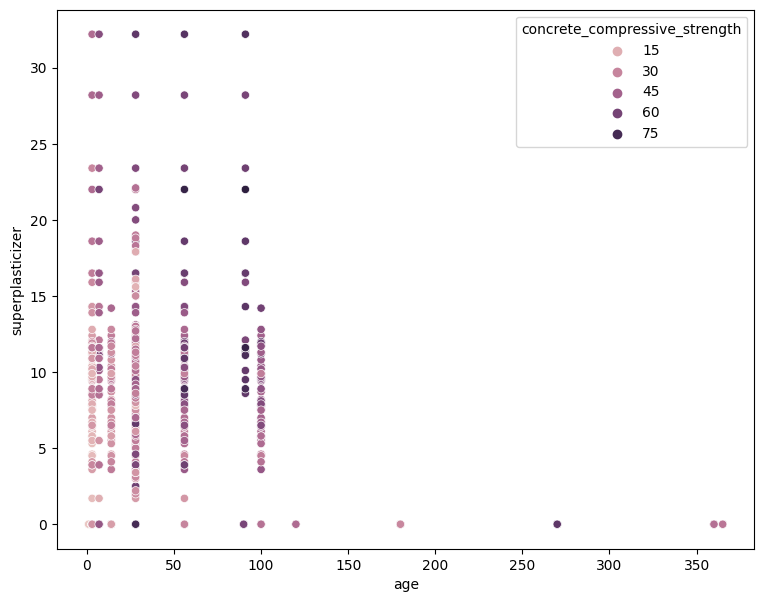

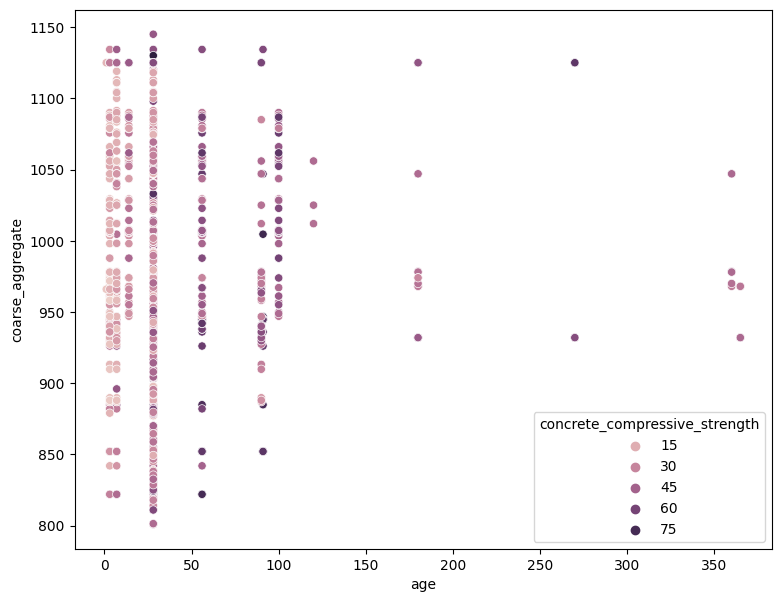

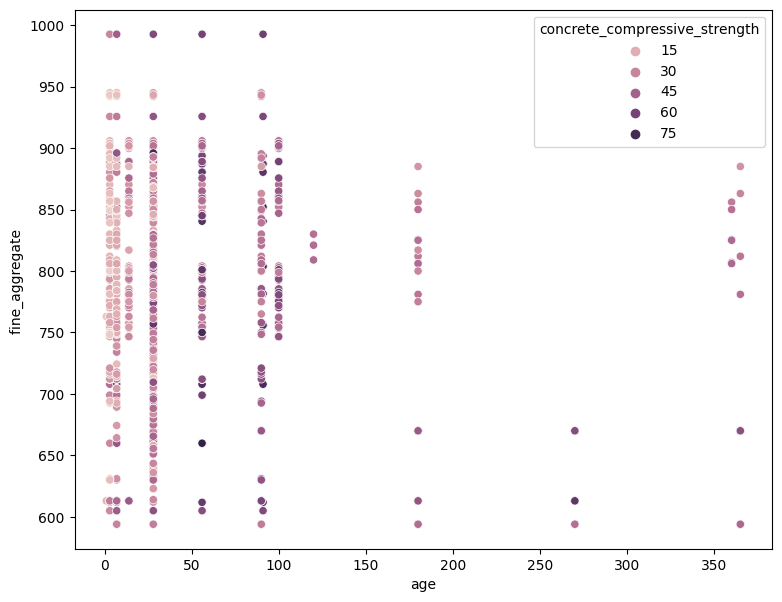

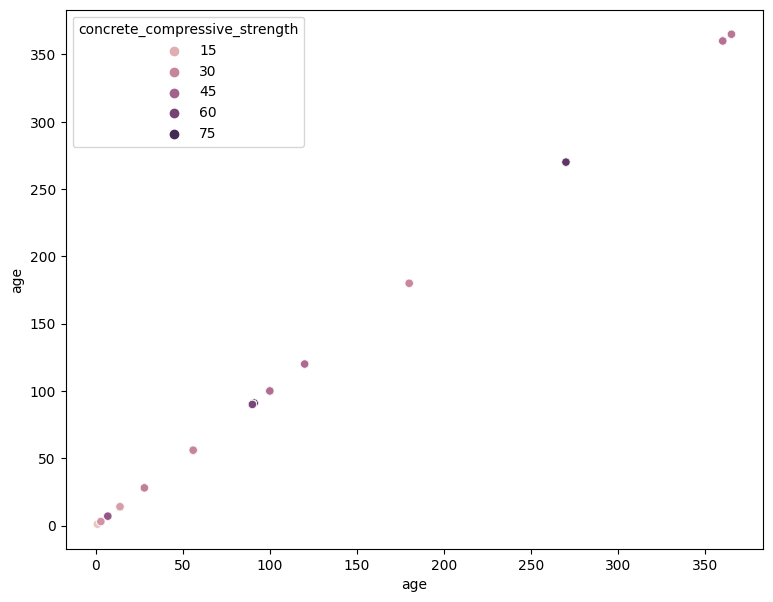

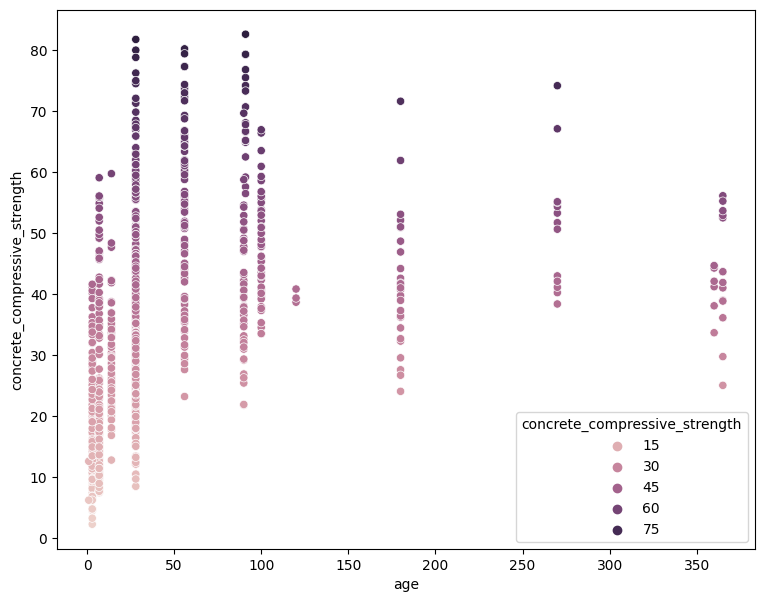

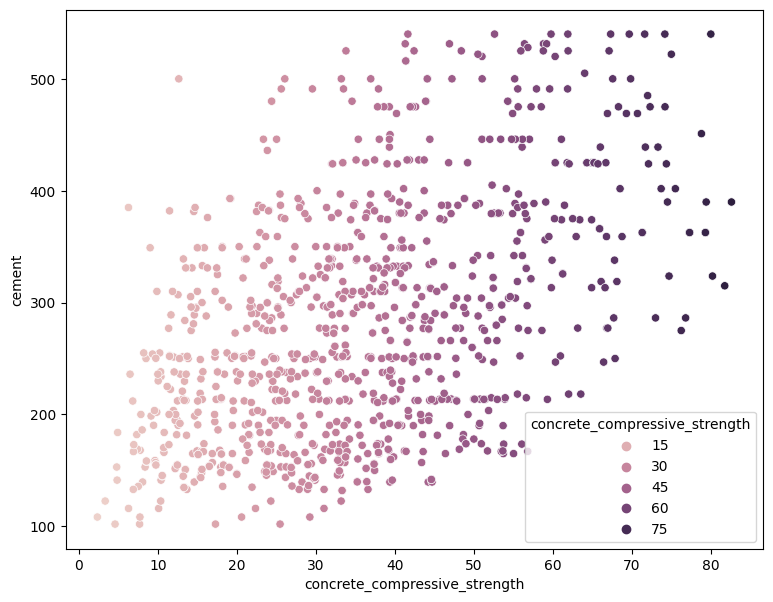

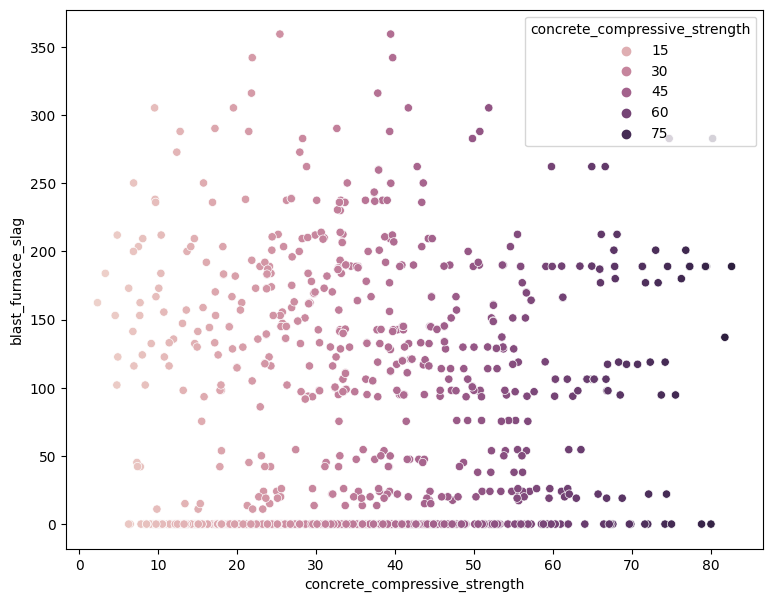

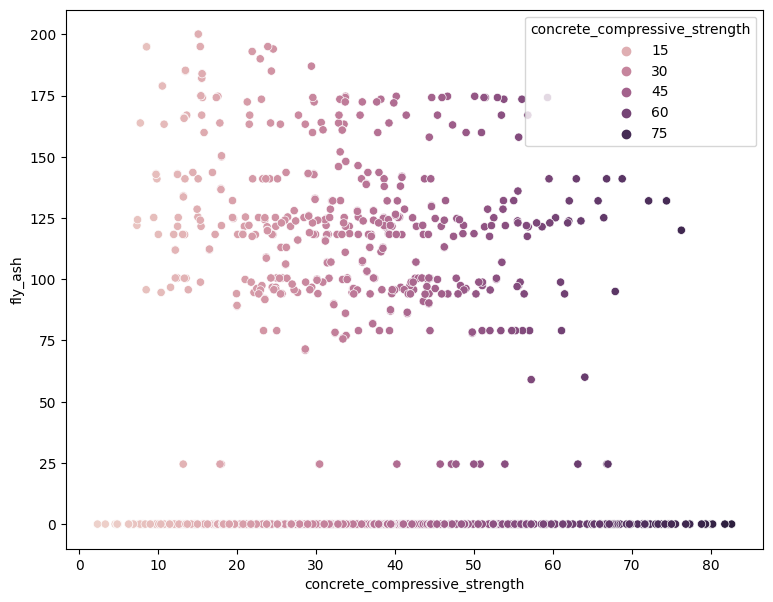

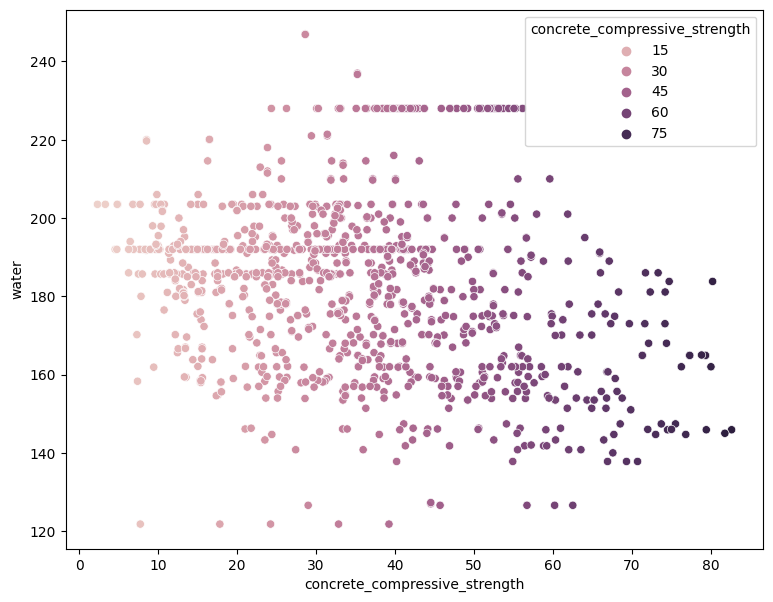

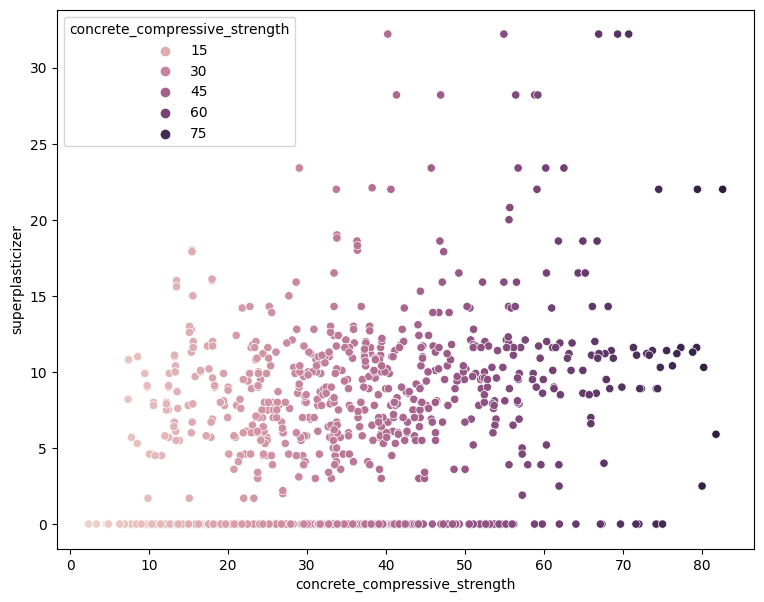

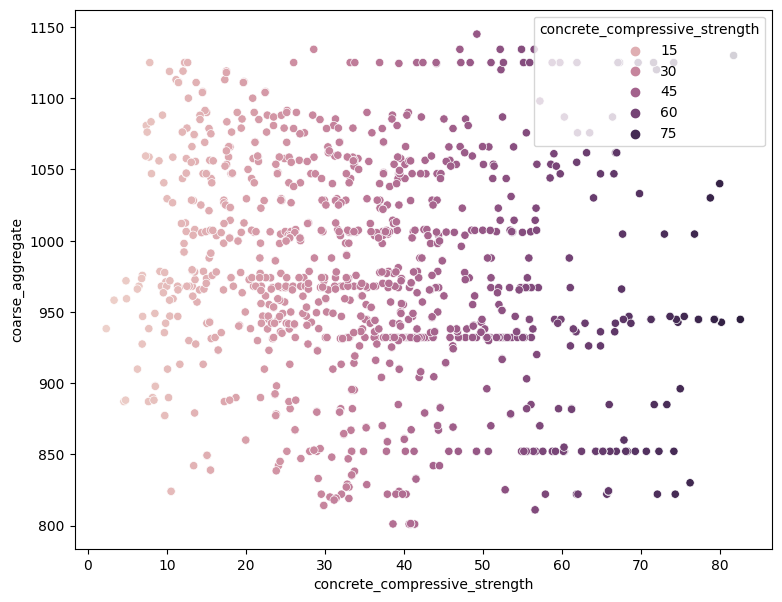

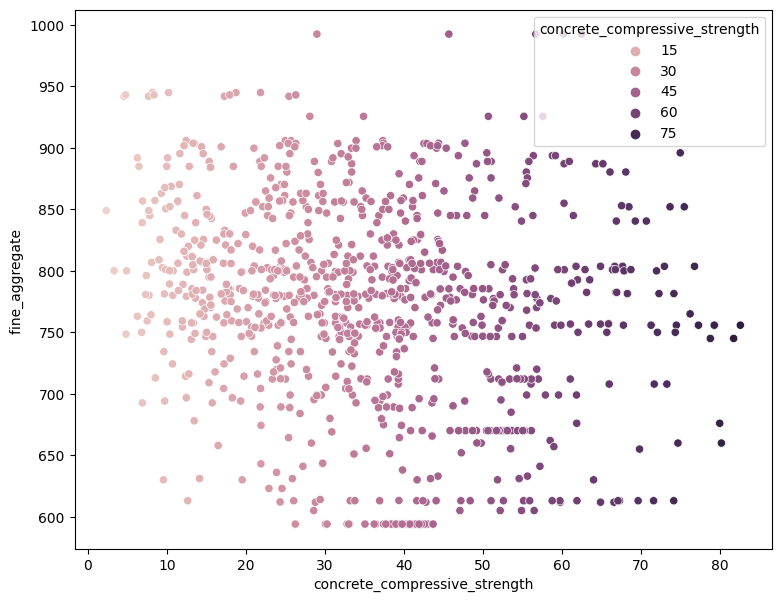

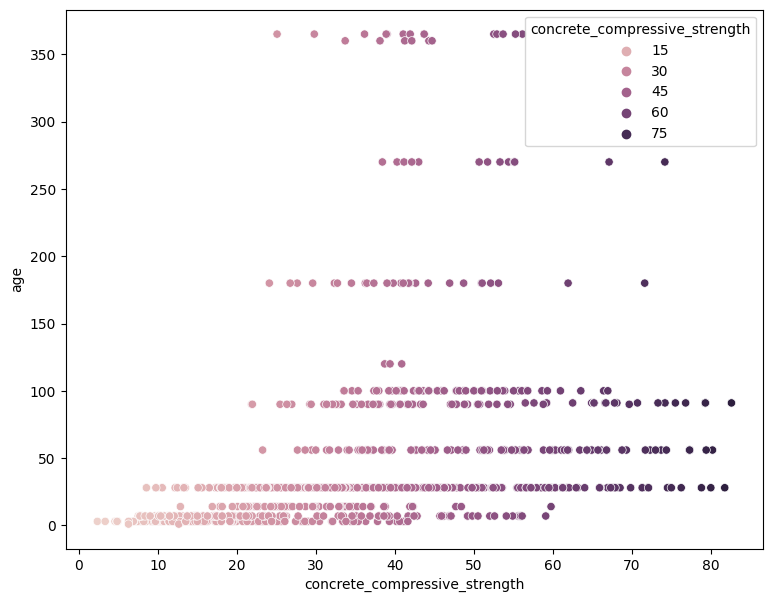

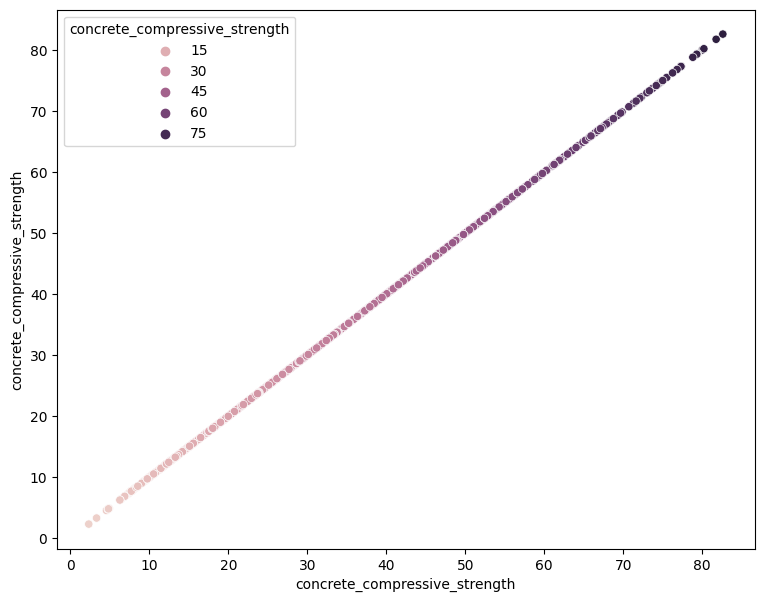

In [65]:
for i in df.columns:
    for j in df.columns:
        plt.figure(figsize=(9,7))
        sns.scatterplot(x=i,y=j,hue="concrete_compressive_strength",data=df)
        plt.show()

### Outlier Analysis

In [66]:
def outlier(data,column):
    plt.figure(figsize=(5,3))
    sns.boxplot(data[column])
    plt.title("{} distribution".format(column))

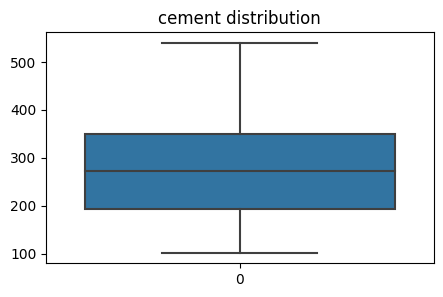

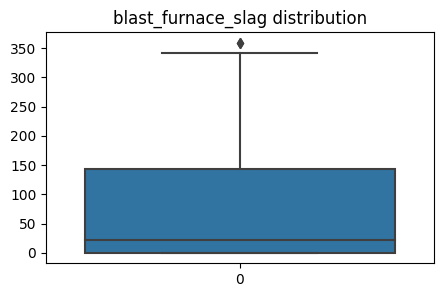

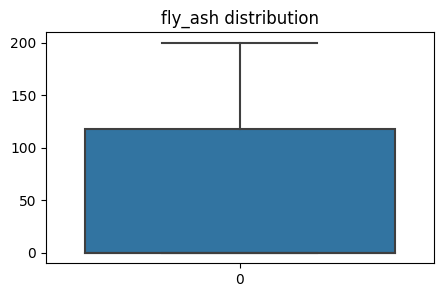

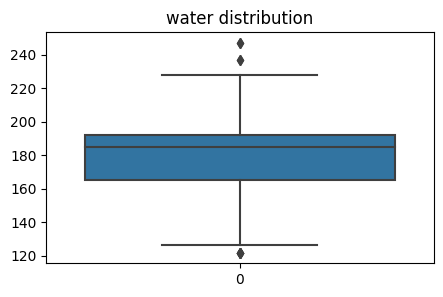

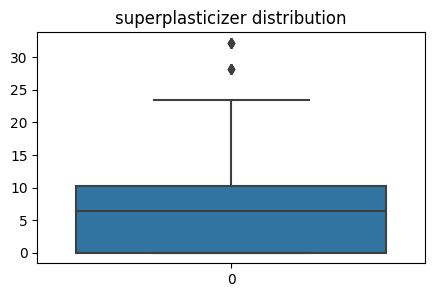

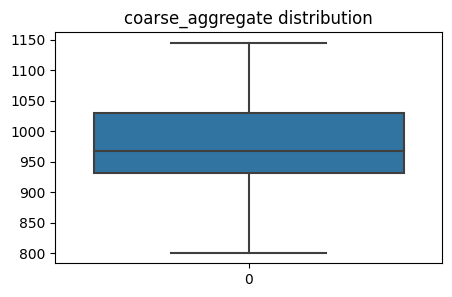

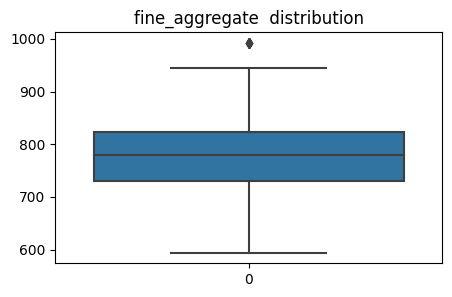

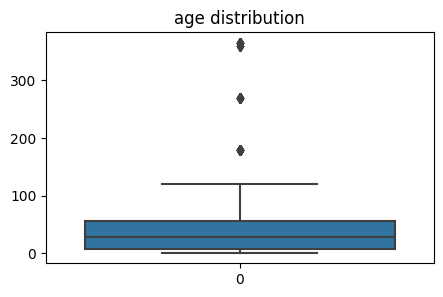

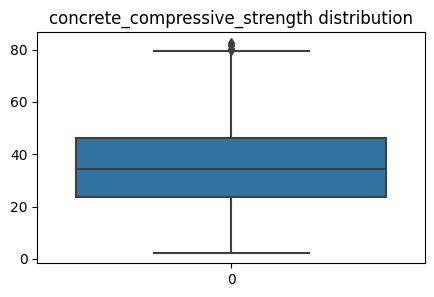

In [67]:
for i in df.columns:
    outlier(df,i)

#### Findind the min and max value for every feature

In [68]:
def end_value_show(data,column):
    print("min value of {} is {} \nmax value of {} is {}".format(column,data[column].min(),column,data[column].max()))

In [69]:
for i in df.columns:
    end_value_show(df,i)

min value of cement is 102.0 
max value of cement is 540.0
min value of blast_furnace_slag is 0.0 
max value of blast_furnace_slag is 359.4
min value of fly_ash is 0.0 
max value of fly_ash is 200.1
min value of water is 121.8 
max value of water is 247.0
min value of superplasticizer is 0.0 
max value of superplasticizer is 32.2
min value of coarse_aggregate is 801.0 
max value of coarse_aggregate is 1145.0
min value of fine_aggregate  is 594.0 
max value of fine_aggregate  is 992.6
min value of age is 1 
max value of age is 365
min value of concrete_compressive_strength is 2.33 
max value of concrete_compressive_strength is 82.6


#### Replacing the Outliers

In [70]:
df=df[df["blast_furnace_slag"]<350]
df=df[(df["water"]<246) & (df["water"]>122)]
df=df[df["superplasticizer"]<25]
df=df[df["age"]<150]
### Feature Engineering

In [74]:
df.columns

Index(['cement', 'fly_ash', 'water', 'superplasticizer', 'age',
       'concrete_compressive_strength'],
      dtype='object')

In [55]:
df.columns

Index(['cement', 'fly_ash', 'water', 'superplasticizer', 'age',
       'concrete_compressive_strength'],
      dtype='object')

<Axes: >

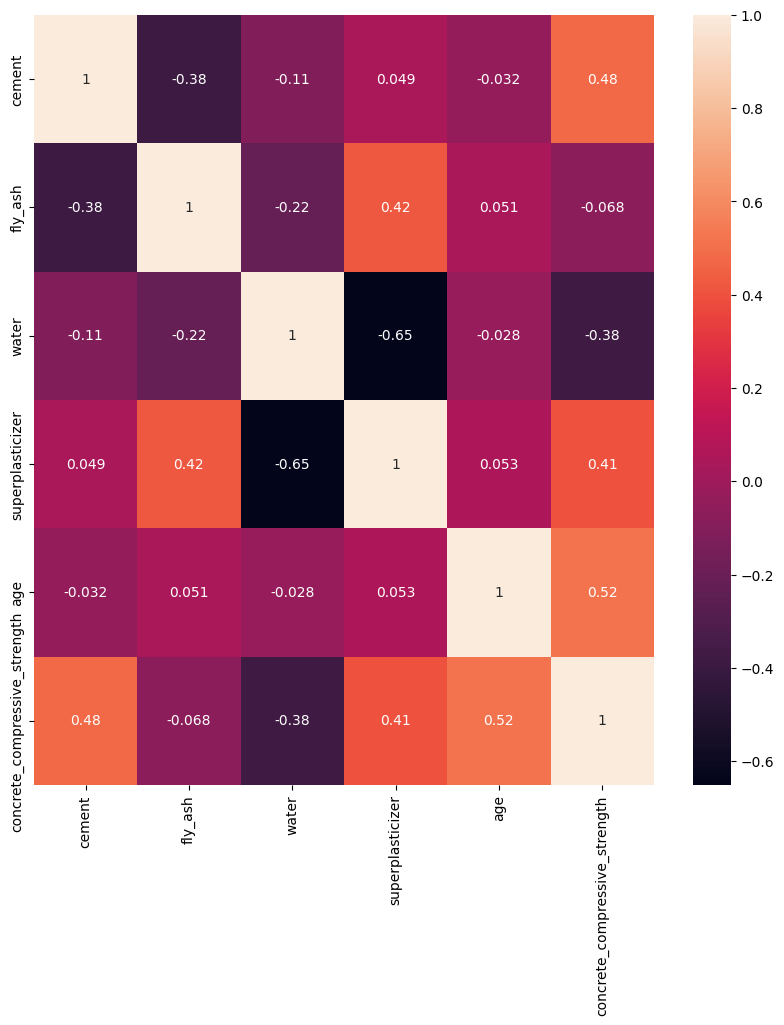

In [28]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)

### Splitting the Data

In [29]:
x=df.drop(["concrete_compressive_strength"],axis=1)
y=df["concrete_compressive_strength"]

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [32]:
x_train.shape

(666, 5)

## Model Building using DL

### We will be using Keras Sequential Model for this project

In [33]:
from tensorflow.keras import models,layers

In [34]:
model=models.Sequential()
model.add(layers.Dropout(0.1))
model.add(layers.Dense(100,activation='relu',input_shape=(x_train.iloc[1].shape)))
model.add(layers.Dropout(0.7))
model.add(layers.Dense(5,activation='tanh'))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(1))
model.compile(optimizer='rmsprop',loss='mse',metrics=['mae'])

In [35]:
model.fit(x_train,y_train,epochs=100,batch_size=1,validation_data=(x_test,y_test))

Epoch 1/100
666/666 [==============================] - 2s 2ms/step - loss: 1442.2592 - mae: 33.9614 - val_loss: 1249.2068 - val_mae: 31.1950
Epoch 2/100
666/666 [==============================] - 1s 2ms/step - loss: 1257.3070 - mae: 31.0975 - val_loss: 1096.3142 - val_mae: 28.6583
Epoch 3/100
666/666 [==============================] - 1s 2ms/step - loss: 1087.5864 - mae: 28.2727 - val_loss: 942.9961 - val_mae: 25.8919
Epoch 4/100
666/666 [==============================] - 1s 2ms/step - loss: 931.6346 - mae: 25.6183 - val_loss: 805.5232 - val_mae: 23.2267
Epoch 5/100
666/666 [==============================] - 1s 2ms/step - loss: 796.0560 - mae: 23.1740 - val_loss: 687.2458 - val_mae: 20.9390
Epoch 6/100
666/666 [==============================] - 1s 2ms/step - loss: 682.2939 - mae: 21.1018 - val_loss: 588.8341 - val_mae: 19.1185
Epoch 7/100
666/666 [==============================] - 1s 2ms/step - loss: 606.8223 - mae: 19.5300 - val_loss: 511.6297 - val_mae: 17.5917
Epoch 8/100
666/666 [=

In [36]:
model.evaluate(x_test,y_test)

9/9 [==============================] - 0s 3ms/step - loss: 276.5968 - mae: 13.1491


[276.5967712402344, 13.149130821228027]

In [37]:
pred=model.predict(x_test)
pred[4]

9/9 [==============================] - 0s 2ms/step


array([34.11036], dtype=float32)

## Using Auto Keras

 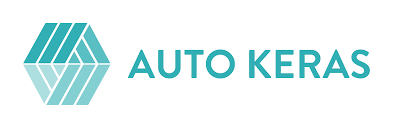

## AutoKeras: An AutoML system based on Keras. It is developed by DATA Lab at Texas A&M University

## Installing Auto Keras

In [38]:
!pip install git+https://github.com/keras-team/keras-tuner.git@1.0.2rc1


Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/keras-team/keras-tuner.git (to revision 1.0.2rc1) to /tmp/pip-req-build-f3qhr138
  Running command git clone --filter=blob:none --quiet https://github.com/keras-team/keras-tuner.git /tmp/pip-req-build-f3qhr138
  Running command git checkout -q 0fb69434a132093518e0e53d40020145ae192629
  Resolved https://github.com/keras-team/keras-tuner.git to commit 0fb69434a132093518e0e53d40020145ae192629
  Preparing metadata (setup.py) ... done
  Created wheel for keras-tuner: filename=keras_tuner-1.0.2rc1-py3-none-any.whl size=85441 sha256=627b75ce4ee4fee162cb985f3874b98016e2c0c38a3eb29b6fb5a306fc1ec230
  Stored in directory: /tmp/pip-ephem-wheel-cache-chonszvh/wheels/b8/e6/44/4b6aa4a149abdabe9752582dbd7d7ae0848e87fe71cd2c59ed
Successfully built keras-tuner
  Attempting uninstall: keras-tuner
    Found existing installation: keras-tuner 1.3.5
    Uninstalling keras-tuner-1.3.5:
      Successful

In [39]:
!pip install autokeras

Defaulting to user installation because normal site-packages is not writeable


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.9/128.9 kB 238.9 kB/s eta 0:00:00 kB/s eta 0:00:01:01
  Attempting uninstall: keras-tuner
    Found existing installation: keras-tuner 1.0.2rc1
    Uninstalling keras-tuner-1.0.2rc1:
      Successfully uninstalled keras-tuner-1.0.2rc1


In [40]:
!pip show autokeras

Name: autokeras
Version: 1.1.0
Summary: AutoML for deep learning
Home-page: http://autokeras.com
Author: DATA Lab, Keras Team
Author-email: jhfjhfj1@gmail.com
License: Apache License 2.0
Location: /home/kalyangopu/.local/lib/python3.10/site-packages
Requires: keras-nlp, keras-tuner, packaging, pandas, tensorflow
Required-by: 


In [41]:
import numpy as np
import pandas as pd
import tensorflow as tf


import autokeras as ak

In [42]:
reg = ak.StructuredDataRegressor(
    overwrite=True, max_trials=3
)

In [43]:
reg.fit(x=x_train, y=y_train, verbose=0)

INFO:tensorflow:Oracle triggered exit
INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets


INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets


In [44]:
# evaluate the model
mae, _  = reg.evaluate(x_test, y_test, verbose=0)
#print('MAE: %.3f' % mae)
# use the model to make a prediction
yhat_test = reg.predict(x_test)

# get the best performing model
model = reg.export_model()


9/9 [==============================] - 0s 960us/step


In [45]:
# summarize the loaded model
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5)]               0         
                                                                 
 multi_category_encoding (M  (None, 5)                 0         
 ultiCategoryEncoding)                                           
                                                                 
 normalization (Normalizati  (None, 5)                 11        
 on)                                                             
                                                                 
 dense (Dense)               (None, 32)                192       
                                                                 
 re_lu (ReLU)                (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                1056  

In [46]:
yhat_test

array([[42.212673 ],
       [42.000244 ],
       [19.758476 ],
       [24.03886  ],
       [14.588943 ],
       [14.065639 ],
       [46.08612  ],
       [16.223377 ],
       [33.411594 ],
       [41.43487  ],
       [16.369978 ],
       [42.34855  ],
       [48.81795  ],
       [22.486603 ],
       [31.737955 ],
       [52.811142 ],
       [49.387283 ],
       [34.269054 ],
       [61.867645 ],
       [31.253765 ],
       [61.20002  ],
       [18.406746 ],
       [59.98831  ],
       [44.1027   ],
       [15.533346 ],
       [35.541096 ],
       [22.561214 ],
       [18.561028 ],
       [35.77884  ],
       [ 6.99612  ],
       [29.95946  ],
       [25.55806  ],
       [47.708054 ],
       [55.754032 ],
       [43.522247 ],
       [75.552765 ],
       [25.029415 ],
       [66.5692   ],
       [23.78041  ],
       [40.651085 ],
       [35.736435 ],
       [58.142044 ],
       [27.826061 ],
       [56.090057 ],
       [58.03174  ],
       [42.464493 ],
       [42.394455 ],
       [19.60

In [43]:
y_test

248    44.30
469    44.28
757    18.13
826    24.39
557    17.24
       ...  
862    35.23
513    40.29
939    32.72
454    39.64
277    36.97
Name: concrete_compressive_strength, Length: 286, dtype: float64

In [47]:
import autokeras as ak

In [48]:
df['age'] = df['age'].astype(float)
x_age = df.drop(["concrete_compressive_strength", "age"], axis=1)
y_age = df["age"]

In [49]:
x_age_train, x_age_test, y_age_train, y_age_test = train_test_split(x_age, y_age, test_size=0.3, random_state=42)


In [50]:
# Build and train the AutoKeras model for predicting concrete age
reg_age = ak.StructuredDataRegressor(overwrite=True, max_trials=3)
reg_age.fit(x=x_age_train, y=y_age_train, verbose=0)

INFO:tensorflow:Oracle triggered exit


INFO:tensorflow:Oracle triggered exit


INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets


INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets


In [51]:
# Evaluate the AutoKeras model
mae_age, _ = reg_age.evaluate(x_age_test, y_age_test, verbose=0)
print('MAE for Age Prediction: %.3f' % mae_age)

MAE for Age Prediction: 834.674


In [52]:
# Use the AutoKeras model to make predictions on the test set
yhat_age_test = reg_age.predict(x_age_test)

# Get the best performing model for age prediction
model_age = reg_age.export_model()

# Summarize the loaded model for age prediction
model_age.summary()

# Predicted ages
print("Predicted Ages:", yhat_age_test)
# Actual ages
print("Actual Ages:", y_age_test)

9/9 [==============================] - 0s 1ms/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 4)]               0         
                                                                 
 multi_category_encoding (M  (None, 4)                 0         
 ultiCategoryEncoding)                                           
                                                                 
 normalization (Normalizati  (None, 4)                 9         
 on)                                                             
                                                                 
 dense (Dense)               (None, 32)                160       
                                                                 
 re_lu (ReLU)                (None, 32)                0         
                                                                 
 dense_1 (